<div style="background: linear-gradient(90deg, #0B1F3A, #123C69); padding: 26px; border-radius: 14px; color: white;">

# FinSight AI — Análise Exploratória e Auditoria dos Dados

### Validação da base financeira para previsão de caixa, risco de liquidez, alertas e insights com IA

Este notebook representa a primeira etapa analítica do projeto **FinSight AI**, uma plataforma inteligente desenvolvida para transformar dados financeiros operacionais em indicadores, previsões, alertas e recomendações de negócio.

O objetivo desta análise é avaliar a qualidade, consistência, distribuição e prontidão dos dados carregados no PostgreSQL, garantindo que a base esteja adequada para as próximas etapas de engenharia de atributos, modelagem preditiva, score de liquidez, geração de alertas financeiros e insights com LLM.

</div>

---

## Objetivo da Análise

Nesta etapa, vamos investigar todas as tabelas do schema `finsight`, avaliando se os dados possuem volume, distribuição, consistência temporal e qualidade suficiente para avançar para os próximos notebooks do projeto.

A análise será focada em:

* inventário das tabelas existentes no banco;
* volume de registros por tabela;
* identificação de tabelas vazias esperadas e não esperadas;
* verificação de nulos;
* verificação de duplicidades;
* análise de faixas temporais;
* distribuição por empresa, setor e porte;
* comportamento de entradas, saídas e saldo;
* distribuição das transações por tipo e categoria;
* análise de contas a receber;
* análise de contas a pagar;
* análise de empréstimos;
* análise do cenário macroeconômico;
* análise de eventos empresariais;
* análise de anomalias financeiras;
* validação das views analíticas;
* diagnóstico final de prontidão para engenharia de atributos e modelagem.

---

## Escopo da Auditoria

O schema `finsight` contém tabelas operacionais, auxiliares e analíticas.

Nesta análise, vamos verificar todas as tabelas existentes no banco:

| Grupo             | Tabelas                                                                                                                   | Objetivo                                                                      |
| ----------------- | ------------------------------------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------- |
| Operacionais      | `empresas`, `contas_bancarias`, `clientes`, `fornecedores`, `transacoes`, `contas_receber`, `contas_pagar`, `emprestimos` | Representam a operação financeira das empresas                                |
| Auxiliares        | `cenario_macroeconomico`, `eventos_empresariais`, `anomalias_financeiras`, `parcelas_emprestimos`                         | Enriquecem a análise com contexto, eventos, anomalias e estrutura de parcelas |
| Analíticas finais | `previsoes_fluxo_caixa`, `scores_liquidez`, `alertas_financeiros`, `insights_llm`                                         | Serão preenchidas posteriormente pelos notebooks de modelagem e IA            |

> Observação: as tabelas analíticas finais podem estar vazias neste momento. Isso é esperado, pois elas serão populadas após a etapa de feature engineering, previsão, score, alertas e geração de insights.

---

## Views Utilizadas na Análise

Além das tabelas físicas, este notebook também utiliza as views analíticas criadas no schema `finsight`.

| View                              | Finalidade                                                           |
| --------------------------------- | -------------------------------------------------------------------- |
| `vw_fluxo_caixa_diario`           | Consolida entradas, saídas e saldo por dia                           |
| `vw_fluxo_caixa_mensal`           | Consolida fluxo de caixa por mês e empresa                           |
| `vw_contexto_empresa_mensal`      | Junta fluxo mensal com cenário macroeconômico e eventos empresariais |
| `vw_indicadores_liquidez_empresa` | Resume indicadores de liquidez por empresa                           |
| `vw_contas_receber_abertas`       | Analisa recebíveis em aberto ou vencidos                             |
| `vw_contas_pagar_abertas`         | Analisa obrigações em aberto ou vencidas                             |
| `vw_anomalias_empresa`            | Consolida anomalias financeiras por empresa                          |

---

## Perguntas de Negócio

Durante a análise, buscamos responder perguntas como:

1. As tabelas principais possuem volume suficiente de dados?
2. Existem tabelas vazias que deveriam estar carregadas?
3. Há nulos em campos críticos como empresa, data, valor ou status?
4. Existem chaves duplicadas?
5. O histórico mensal é suficiente para criar lags e médias móveis?
6. As empresas estão distribuídas por diferentes setores e portes?
7. O fluxo de caixa possui variação suficiente para modelagem?
8. Existem contas a receber vencidas ou em aberto?
9. Existem contas a pagar vencidas ou em aberto?
10. Os empréstimos geram pressão financeira relevante?
11. O cenário macroeconômico cobre o período analisado?
12. Existem eventos empresariais e anomalias suficientes para enriquecer os modelos?
13. A base está pronta para avançar para engenharia de atributos?

---

## Critérios de Prontidão para os Próximos Notebooks

Ao final deste notebook, a base será considerada pronta se atender aos seguintes critérios:

<div style="background-color: #F3F7FA; padding: 14px; border-left: 5px solid #1F77B4; border-radius: 8px;">

<b>Critérios principais:</b>

* tabelas operacionais carregadas com dados;
* histórico mensal suficiente por empresa;
* presença de entradas, saídas e saldo financeiro;
* dados disponíveis para contas a receber e contas a pagar;
* dados de empréstimos disponíveis;
* cenário macroeconômico cobrindo o período analisado;
* eventos empresariais disponíveis;
* anomalias financeiras disponíveis;
* views analíticas funcionando corretamente;
* ausência de problemas críticos de nulos ou duplicidades.

</div>

---

## Próximas Etapas do Projeto

Após esta análise exploratória e auditoria da base, o projeto seguirá para os seguintes notebooks:

<div style="background-color: #F3F7FA; padding: 14px; border-left: 5px solid #1F77B4; border-radius: 8px;">

<b>02_feature_engineering.ipynb</b>
Criação de atributos para modelos preditivos, como lags, médias móveis, volatilidade, sazonalidade, inadimplência, endividamento, indicadores macroeconômicos e flags de eventos.

<br><br>

<b>03_cashflow_forecasting_model.ipynb</b>
Treinamento de modelos para previsão de fluxo de caixa futuro, utilizando o histórico mensal de entradas, saídas e saldo por empresa.

<br><br>

<b>04_liquidity_score_model.ipynb</b>
Construção de um score de risco de liquidez por empresa, combinando fluxo de caixa, contas vencidas, endividamento, previsão de caixa e indicadores financeiros.

<br><br>

<b>05_alertas_financeiros.ipynb</b>
Geração de alertas financeiros com base em risco de liquidez, caixa previsto negativo, inadimplência, obrigações vencidas e anomalias financeiras.

<br><br>

<b>06_llm_insights.ipynb</b>
Geração de explicações, recomendações e resumos executivos em linguagem natural com apoio de LLM.

</div>

---

## Contexto Técnico

<div style="background-color: #EAF7EA; padding: 14px; border-left: 5px solid #2E8B57; border-radius: 8px;">

<b>Stack utilizada:</b>

* Docker Compose para orquestração dos serviços;
* PostgreSQL para armazenamento e modelagem dos dados;
* pgAdmin para administração visual do banco;
* Jupyter Lab para análise exploratória;
* Python para
* Seaborn para visualizações avançadas. análise, visualização e modelagem;
* Pandas para manipulação dos dados;
* SQLAlchemy para conexão com o PostgreSQL;
* Matplotlib para visualizações iniciais.

</div>

---

## Resultado Esperado deste Notebook

Ao final desta análise, teremos um diagnóstico claro sobre a qualidade e a maturidade da base de dados.

O resultado esperado é confirmar se os dados estão prontos para avançar para o notebook:

```text
02_feature_engineering.ipynb
```

A partir dele, criaremos a base modelável que alimentará os notebooks de previsão, score de liquidez, alertas financeiros e insights com LLM.
nálise exploratória;
* Python, Pandas, SQLAlchemy e Matplotlib para análise e visualização.

</div>


In [1]:
!pip install psycopg2-binary -q
!pip install sqlalchemy pandas python-dotenv -q
!pip install seaborn -q

In [2]:
import os

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine
from sqlalchemy.engine import URL

In [3]:
db_host = os.getenv("DB_HOST")
db_port = os.getenv("DB_PORT")
db_name = os.getenv("DB_NAME")
db_user = os.getenv("DB_USER")
db_password = os.getenv("DB_PASSWORD")

print("DB_HOST:", db_host)
print("DB_PORT:", db_port)
print("DB_NAME:", db_name)
print("DB_USER:", db_user)

DB_HOST: postgres
DB_PORT: 5432
DB_NAME: finsight
DB_USER: finsight_user


In [4]:
database_url = URL.create(
    drivername="postgresql+psycopg2",
    username=db_user,
    password=db_password,
    host=db_host,
    port=int(db_port),
    database=db_name,
)

engine = create_engine(database_url)

In [5]:
queries = {
    "fluxo_diario": """
        SELECT *
        FROM finsight.vw_fluxo_caixa_diario;
    """,

    "fluxo_mensal": """
        SELECT *
        FROM finsight.vw_fluxo_caixa_mensal;
    """,

    "contexto_mensal": """
        SELECT *
        FROM finsight.vw_contexto_empresa_mensal;
    """,

    "liquidez": """
        SELECT *
        FROM finsight.vw_indicadores_liquidez_empresa;
    """,

    "contas_receber_abertas": """
        SELECT *
        FROM finsight.vw_contas_receber_abertas;
    """,

    "contas_pagar_abertas": """
        SELECT *
        FROM finsight.vw_contas_pagar_abertas;
    """,

    "anomalias": """
        SELECT *
        FROM finsight.vw_anomalias_empresa;
    """
}

dfs = {}

for nome, query in queries.items():
    dfs[nome] = pd.read_sql(query, engine)
    print(f"{nome:<25} {dfs[nome].shape}")

fluxo_diario              (22786, 9)
fluxo_mensal              (876, 11)
contexto_mensal           (876, 14)
liquidez                  (20, 22)
contas_receber_abertas    (2749, 17)
contas_pagar_abertas      (192, 16)
anomalias                 (298, 14)


## 1. As tabelas principais possuem volume suficiente de dados?

Nesta etapa, avaliamos o volume de registros em todas as tabelas do schema `finsight`, separando tabelas operacionais, auxiliares e analíticas finais.

As tabelas analíticas finais podem estar vazias neste momento, pois serão preenchidas posteriormente pelos notebooks de previsão, score de liquidez, alertas financeiros e insights com LLM.

In [6]:
query_tables = """
SELECT
    table_name 
FROM information_schema.tables
WHERE table_schema = 'finsight'
  AND table_type = 'BASE TABLE'
ORDER BY table_name;
"""

tabelas = pd.read_sql(query_tables, engine)
tabelas

,table_name
0,alertas_financeiros
1,anomalias_financeiras
2,cenario_macroeconomico
3,clientes
4,contas_bancarias
5,contas_pagar
6,contas_receber
7,empresas
8,emprestimos
9,eventos_empresariais


In [7]:
volumes = []

for tabela in tabelas["table_name"]:
    query = f"""
        SELECT COUNT(*) AS qtd_linhas
        FROM finsight.{tabela};
    """
    
    qtd = pd.read_sql(query, engine)["qtd_linhas"].iloc[0]
    
    volumes.append({
        "tabela": tabela,
        "qtd_linhas": qtd
    })

df_volumes = pd.DataFrame(volumes).sort_values("qtd_linhas", ascending=False)
df_volumes

,tabela,qtd_linhas
15,transacoes,74928
6,contas_receber,68976
5,contas_pagar,8400
3,clientes,1761
10,fornecedores,850
1,anomalias_financeiras,298
2,cenario_macroeconomico,42
4,contas_bancarias,35
9,eventos_empresariais,30
8,emprestimos,22


In [8]:
tabelas_esperadas_vazias = [
    "previsoes_fluxo_caixa",
    "scores_liquidez",
    "alertas_financeiros",
    "insights_llm",
    "parcelas_emprestimos"
]

df_volumes["status"] = df_volumes.apply(
    lambda row:
        "OK"
        if row["qtd_linhas"] > 0
        else "Esperado vazio"
        if row["tabela"] in tabelas_esperadas_vazias
        else "Problema: tabela vazia",
    axis=1
)

df_volumes

,tabela,qtd_linhas,status
15,transacoes,74928,OK
6,contas_receber,68976,OK
5,contas_pagar,8400,OK
3,clientes,1761,OK
10,fornecedores,850,OK
1,anomalias_financeiras,298,OK
2,cenario_macroeconomico,42,OK
4,contas_bancarias,35,OK
9,eventos_empresariais,30,OK
8,emprestimos,22,OK


In [9]:
sns.set_theme(
    style="whitegrid",
    context="notebook",
    font_scale=1.05
)

palette_flare = sns.color_palette("flare", as_cmap=False)

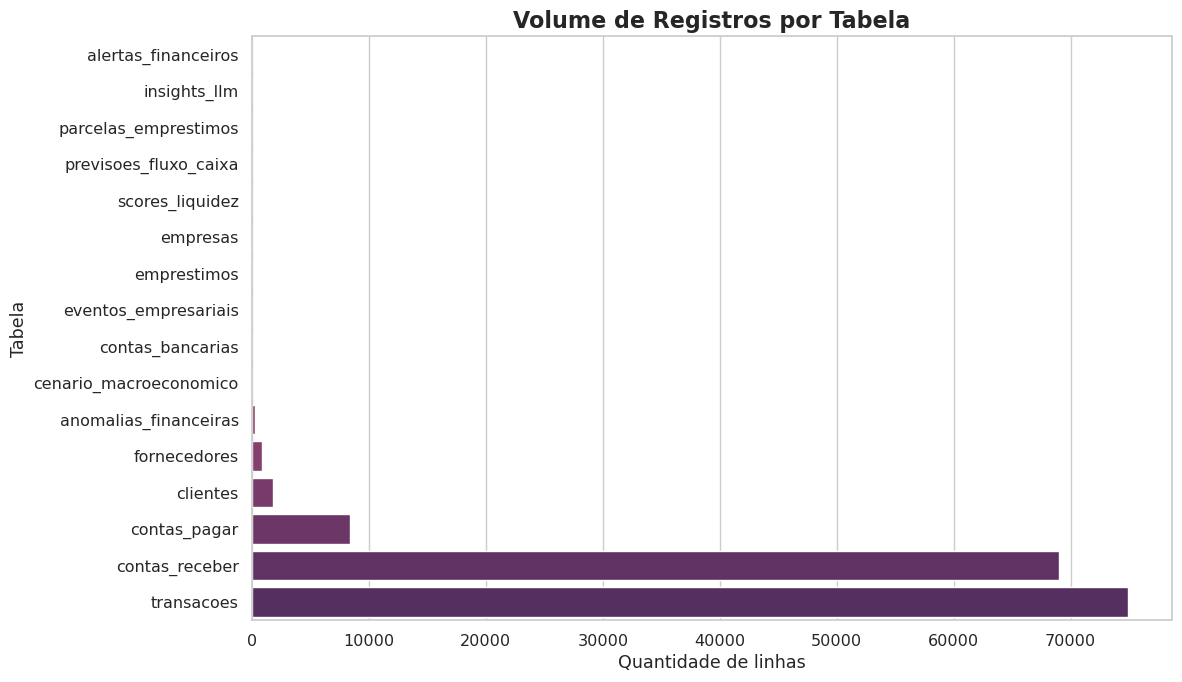

In [10]:
df_volumes_plot = df_volumes.sort_values("qtd_linhas", ascending=True)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=df_volumes_plot,
    x="qtd_linhas",
    y="tabela",
    hue="tabela",
    palette="flare",
    legend=False
)

plt.title("Volume de Registros por Tabela", fontsize=16, weight="bold")
plt.xlabel("Quantidade de linhas")
plt.ylabel("Tabela")
plt.tight_layout()
plt.show()

### Resposta da Pergunta de Negócio 1

## As tabelas principais possuem volume suficiente de dados?

A análise de volume mostra que as principais tabelas operacionais do projeto estão carregadas corretamente e possuem dados suficientes para sustentar as próximas etapas analíticas.

As maiores tabelas são `transacoes`, com **74.928 registros**, e `contas_receber`, com **68.976 registros**. Isso indica que a base possui um volume relevante de movimentações financeiras e recebíveis, o que é essencial para análises de fluxo de caixa, inadimplência, comportamento financeiro e previsão futura.

Também foram carregadas tabelas importantes para enriquecer a análise, como `contas_pagar`, `clientes`, `fornecedores`, `anomalias_financeiras`, `cenario_macroeconomico`, `eventos_empresariais`, `emprestimos`, `contas_bancarias` e `empresas`.

As tabelas `alertas_financeiros`, `insights_llm`, `previsoes_fluxo_caixa` e `scores_liquidez` aparecem vazias de forma esperada, pois serão preenchidas posteriormente pelos notebooks de modelagem, geração de alertas e insights com IA.

A tabela `parcelas_emprestimos` também está vazia neste momento por decisão técnica, já que sua estrutura será tratada posteriormente de forma separada da tabela de contas a pagar.

Portanto, a base possui volume suficiente nas tabelas operacionais e auxiliares para avançar para as próximas análises exploratórias e para o notebook `02_feature_engineering.ipynb`.


<div style="background-color: #EAF7EA; padding: 14px; border-left: 5px solid #2E8B57; border-radius: 8px;"> <b>Conclusão:</b> A base possui volume suficiente nas tabelas principais. Não há indício de falta de dados nas tabelas operacionais necessárias para o `02_feature_engineering.ipynb`. </div>

## 2. Existem tabelas vazias que deveriam estar carregadas?

Nesta etapa, avaliamos se existem tabelas vazias dentro do schema `finsight` e classificamos cada caso como:

- **OK**: tabela carregada com dados;
- **Esperado vazio**: tabela que será preenchida em etapas futuras do projeto;
- **Problema**: tabela operacional ou auxiliar que deveria possuir dados, mas está vazia.

Essa verificação é importante porque uma tabela operacional vazia poderia comprometer a criação de variáveis no `02_feature_engineering.ipynb` e prejudicar os modelos de previsão, score de liquidez, alertas financeiros e insights com LLM.

In [11]:
df_tabelas_vazias = (
    df_volumes
    .query("qtd_linhas == 0")
    .sort_values("tabela")
)

df_tabelas_vazias

,tabela,qtd_linhas,status
0,alertas_financeiros,0,Esperado vazio
11,insights_llm,0,Esperado vazio
12,parcelas_emprestimos,0,Esperado vazio
13,previsoes_fluxo_caixa,0,Esperado vazio
14,scores_liquidez,0,Esperado vazio


In [12]:
tabelas_vazias_problematicas = (
    df_volumes
    .query("qtd_linhas == 0 and status == 'Problema: tabela vazia'")
)

if tabelas_vazias_problematicas.empty:
    print("Nenhuma tabela vazia problemática encontrada.")
else:
    print("Existem tabelas vazias que deveriam estar carregadas:")
    display(tabelas_vazias_problematicas)

Nenhuma tabela vazia problemática encontrada.


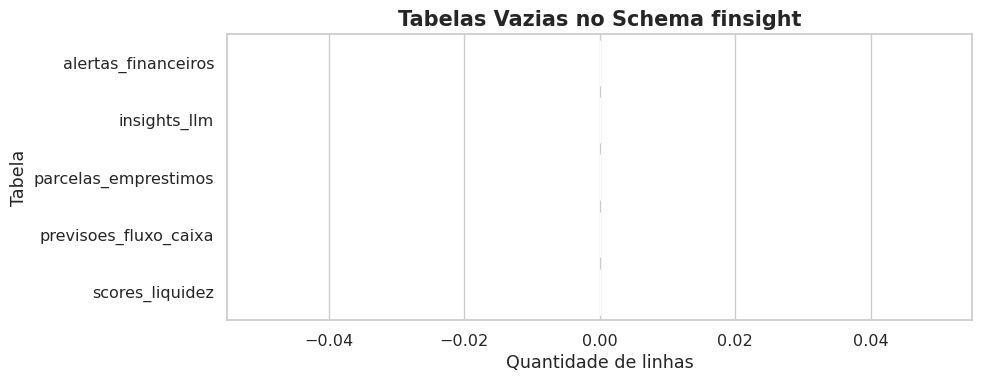

In [13]:
df_tabelas_vazias_plot = df_tabelas_vazias.copy()

plt.figure(figsize=(10, 4))

sns.barplot(
    data=df_tabelas_vazias_plot,
    x="qtd_linhas",
    y="tabela",
    hue="tabela",
    palette="flare",
    legend=False
)

plt.title("Tabelas Vazias no Schema finsight", fontsize=15, weight="bold")
plt.xlabel("Quantidade de linhas")
plt.ylabel("Tabela")
plt.tight_layout()
plt.show()

### Resposta da Pergunta de Negócio 2  
## Existem tabelas vazias que deveriam estar carregadas?

A análise identificou cinco tabelas vazias no schema `finsight`: `alertas_financeiros`, `insights_llm`, `parcelas_emprestimos`, `previsoes_fluxo_caixa` e `scores_liquidez`.

As tabelas `alertas_financeiros`, `insights_llm`, `previsoes_fluxo_caixa` e `scores_liquidez` estão vazias de forma esperada, pois fazem parte da camada analítica final do projeto. Elas serão preenchidas posteriormente pelos notebooks responsáveis por previsão de fluxo de caixa, score de liquidez, geração de alertas financeiros e insights com LLM.

A tabela `parcelas_emprestimos` também está vazia neste momento por decisão técnica. Sua estrutura será tratada posteriormente para separar corretamente as parcelas de empréstimos da lógica de contas a pagar.

Não foram encontradas tabelas operacionais ou auxiliares críticas vazias indevidamente. As tabelas fundamentais para análise e feature engineering, como `empresas`, `transacoes`, `contas_receber`, `contas_pagar`, `clientes`, `fornecedores`, `emprestimos`, `cenario_macroeconomico`, `eventos_empresariais` e `anomalias_financeiras`, possuem dados carregados.

Portanto, não há bloqueio relacionado a tabelas vazias para avançar para o notebook `02_feature_engineering.ipynb`.

<div style="background-color: #EAF7EA; padding: 14px; border-left: 5px solid #2E8B57; border-radius: 8px;"> <b>Conclusão:</b> Nenhuma tabela operacional crítica está vazia indevidamente. As tabelas vazias identificadas são esperadas no estágio atual do projeto e serão preenchidas nas próximas etapas do pipeline analítico. </div>

## 3. Há nulos em campos críticos como empresa, data, valor ou status?

Nesta etapa, avaliamos a presença de valores nulos nas tabelas do schema `finsight`, com foco especial em campos críticos para análise financeira e modelagem.

Campos críticos são colunas que não deveriam estar vazias em tabelas operacionais, como:

- identificadores de empresa;
- datas principais;
- valores financeiros;
- status de contas, pagamentos, recebimentos ou empréstimos;
- tipos e categorias de transações.

Essa verificação é essencial porque valores nulos em campos críticos podem comprometer a criação de variáveis no `02_feature_engineering.ipynb`, afetar os modelos de previsão de fluxo de caixa e prejudicar o cálculo do score de liquidez.

In [14]:
query_tables = """
SELECT
    table_name
FROM information_schema.tables
WHERE table_schema = 'finsight'
  AND table_type = 'BASE TABLE'
ORDER BY table_name;
"""

tabelas = pd.read_sql(query_tables, engine)
tabelas

,table_name
0,alertas_financeiros
1,anomalias_financeiras
2,cenario_macroeconomico
3,clientes
4,contas_bancarias
5,contas_pagar
6,contas_receber
7,empresas
8,emprestimos
9,eventos_empresariais


In [15]:
dfs_tabelas = {}

for tabela in tabelas["table_name"]:
    query = f"""
        SELECT *
        FROM finsight.{tabela};
    """
    
    dfs_tabelas[tabela] = pd.read_sql(query, engine)
    
    print(f"{tabela:<30} {dfs_tabelas[tabela].shape}")

alertas_financeiros            (0, 9)
anomalias_financeiras          (298, 9)
cenario_macroeconomico         (42, 5)
clientes                       (1761, 8)
contas_bancarias               (35, 8)
contas_pagar                   (8400, 10)
contas_receber                 (68976, 10)
empresas                       (20, 9)
emprestimos                    (22, 12)
eventos_empresariais           (30, 9)
fornecedores                   (850, 7)
insights_llm                   (0, 9)
parcelas_emprestimos           (0, 11)
previsoes_fluxo_caixa          (0, 13)
scores_liquidez                (0, 12)
transacoes                     (74928, 10)


In [16]:
relatorio_nulos = []

for tabela, df in dfs_tabelas.items():
    total_linhas = len(df)

    if total_linhas == 0:
        relatorio_nulos.append({
            "tabela": tabela,
            "coluna": "-",
            "qtd_linhas": total_linhas,
            "qtd_nulos": 0,
            "pct_nulos": 0,
            "tipo_coluna": "Tabela vazia",
            "criticidade": "Esperado vazio"
        })
        continue

    for coluna in df.columns:
        qtd_nulos = df[coluna].isna().sum()
        pct_nulos = (qtd_nulos / total_linhas) * 100

        if qtd_nulos > 0:
            relatorio_nulos.append({
                "tabela": tabela,
                "coluna": coluna,
                "qtd_linhas": total_linhas,
                "qtd_nulos": qtd_nulos,
                "pct_nulos": round(pct_nulos, 2),
                "tipo_coluna": str(df[coluna].dtype),
                "criticidade": "A avaliar"
            })

df_nulos = pd.DataFrame(relatorio_nulos)

df_nulos.sort_values(
    ["pct_nulos", "qtd_nulos"],
    ascending=False
)

,tabela,coluna,qtd_linhas,qtd_nulos,pct_nulos,tipo_coluna,criticidade
3,emprestimos,data_proxima_parcela,22,16,72.73,object,A avaliar
2,contas_receber,data_pagamento,68976,2749,3.99,object,A avaliar
1,contas_pagar,data_pagamento,8400,192,2.29,object,A avaliar
0,alertas_financeiros,-,0,0,0.00,Tabela vazia,Esperado vazio
4,insights_llm,-,0,0,0.00,Tabela vazia,Esperado vazio
5,parcelas_emprestimos,-,0,0,0.00,Tabela vazia,Esperado vazio
6,previsoes_fluxo_caixa,-,0,0,0.00,Tabela vazia,Esperado vazio
7,scores_liquidez,-,0,0,0.00,Tabela vazia,Esperado vazio


In [17]:
campos_nulos_esperados = [
    ("contas_receber", "data_pagamento"),
    ("contas_pagar", "data_pagamento"),
    ("emprestimos", "data_proxima_parcela"),
]

palavras_campos_criticos = [
    "id_empresa",
    "valor",
    "status",
    "tipo",
    "categoria",
    "mes_referencia",
    "data_transacao",
    "data_emissao",
    "data_vencimento",
    "data_contratacao",
    "data_inicio",
    "data_fim",
    "data_evento"
]

def classificar_criticidade(row):
    tabela = row["tabela"]
    coluna = row["coluna"]

    tabelas_esperadas_vazias = [
        "previsoes_fluxo_caixa",
        "scores_liquidez",
        "alertas_financeiros",
        "insights_llm",
        "parcelas_emprestimos"
    ]

    if tabela in tabelas_esperadas_vazias:
        return "Esperado vazio"

    if coluna == "-":
        return "Esperado vazio"

    if (tabela, coluna) in campos_nulos_esperados:
        return "Nulo esperado"

    coluna_lower = coluna.lower()

    if any(campo in coluna_lower for campo in palavras_campos_criticos):
        return "Crítico"

    return "Não crítico"


df_nulos["criticidade"] = df_nulos.apply(classificar_criticidade, axis=1)

df_nulos.sort_values(
    ["criticidade", "pct_nulos"],
    ascending=[True, False]
)

,tabela,coluna,qtd_linhas,qtd_nulos,pct_nulos,tipo_coluna,criticidade
0,alertas_financeiros,-,0,0,0.00,Tabela vazia,Esperado vazio
4,insights_llm,-,0,0,0.00,Tabela vazia,Esperado vazio
5,parcelas_emprestimos,-,0,0,0.00,Tabela vazia,Esperado vazio
6,previsoes_fluxo_caixa,-,0,0,0.00,Tabela vazia,Esperado vazio
7,scores_liquidez,-,0,0,0.00,Tabela vazia,Esperado vazio
3,emprestimos,data_proxima_parcela,22,16,72.73,object,Nulo esperado
2,contas_receber,data_pagamento,68976,2749,3.99,object,Nulo esperado
1,contas_pagar,data_pagamento,8400,192,2.29,object,Nulo esperado


In [18]:
df_nulos_criticos = (
    df_nulos
    .query("criticidade == 'Crítico'")
    .sort_values(["pct_nulos", "qtd_nulos"], ascending=False)
)

if df_nulos_criticos.empty:
    print("Nenhum nulo crítico encontrado nas tabelas operacionais e auxiliares.")
else:
    print("Foram encontrados nulos em campos críticos:")
    display(df_nulos_criticos)

Nenhum nulo crítico encontrado nas tabelas operacionais e auxiliares.


In [19]:
resumo_nulos = (
    df_nulos
    .groupby("criticidade", as_index=False)
    .agg(
        qtd_colunas_com_nulos=("coluna", "count"),
        qtd_nulos_total=("qtd_nulos", "sum"),
        media_pct_nulos=("pct_nulos", "mean")
    )
    .sort_values("qtd_nulos_total", ascending=False)
)

resumo_nulos

,criticidade,qtd_colunas_com_nulos,qtd_nulos_total,media_pct_nulos
1,Nulo esperado,3,2957,26.336667
0,Esperado vazio,5,0,0.000000


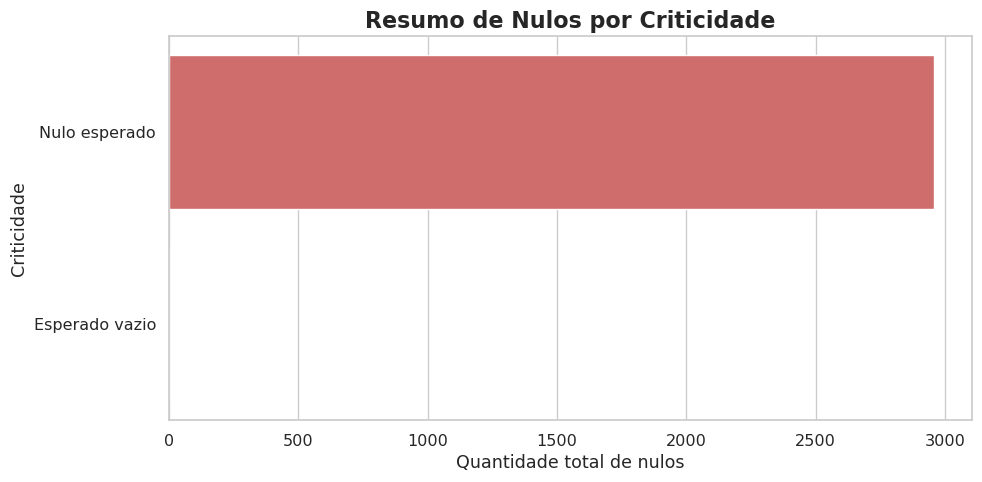

In [20]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=resumo_nulos,
    x="qtd_nulos_total",
    y="criticidade",
    hue="criticidade",
    palette="flare",
    legend=False
)

plt.title("Resumo de Nulos por Criticidade", fontsize=16, weight="bold")
plt.xlabel("Quantidade total de nulos")
plt.ylabel("Criticidade")
plt.tight_layout()
plt.show()

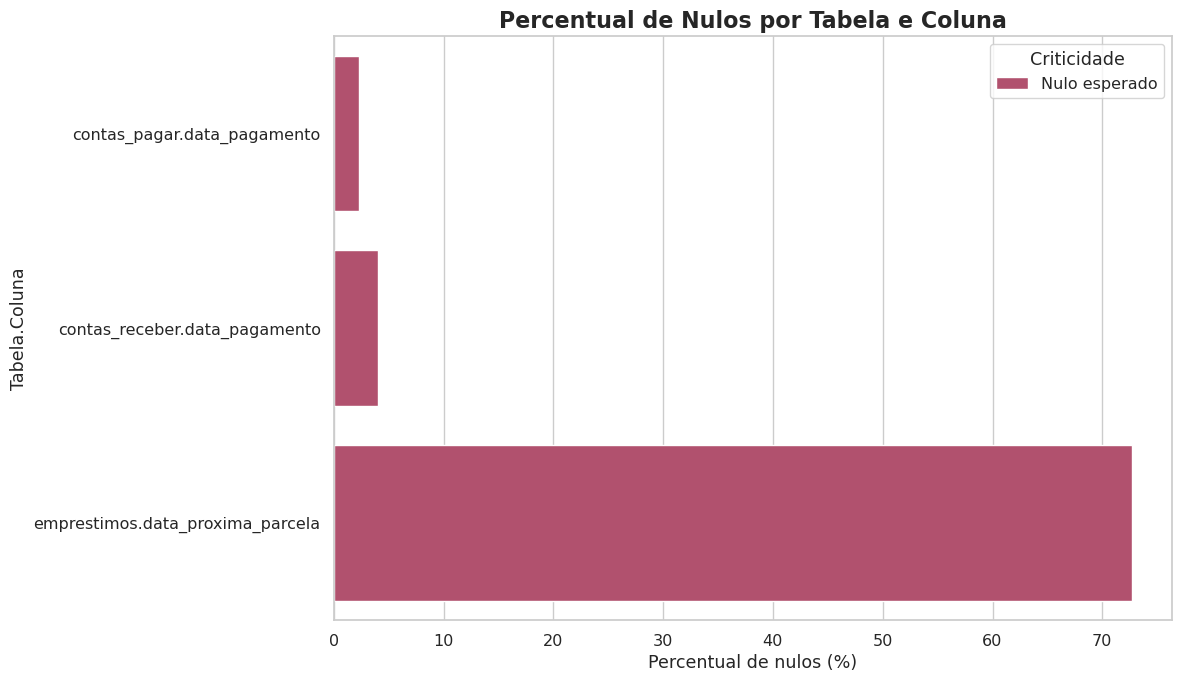

In [21]:
df_nulos_plot = (
    df_nulos
    .query("qtd_nulos > 0")
    .copy()
)

df_nulos_plot["tabela_coluna"] = (
    df_nulos_plot["tabela"] + "." + df_nulos_plot["coluna"]
)

df_nulos_plot = df_nulos_plot.sort_values("pct_nulos", ascending=True)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=df_nulos_plot,
    x="pct_nulos",
    y="tabela_coluna",
    hue="criticidade",
    palette="flare"
)

plt.title("Percentual de Nulos por Tabela e Coluna", fontsize=16, weight="bold")
plt.xlabel("Percentual de nulos (%)")
plt.ylabel("Tabela.Coluna")
plt.legend(title="Criticidade")
plt.tight_layout()
plt.show()

### Resposta da Pergunta de Negócio 3  
## Há nulos em campos críticos como empresa, data, valor ou status?

A análise de nulos avaliou todas as tabelas do schema `finsight`, com foco em campos essenciais para análise financeira e modelagem, como identificadores de empresa, datas principais, valores financeiros, status, tipos e categorias.

Foram encontrados nulos em três campos: `contas_receber.data_pagamento`, `contas_pagar.data_pagamento` e `emprestimos.data_proxima_parcela`.

Os nulos em `data_pagamento` são esperados, pois representam contas que ainda estão em aberto, vencidas ou pendentes de pagamento. Portanto, esses campos não indicam erro de carga ou problema de qualidade.

O campo `emprestimos.data_proxima_parcela` também possui nulos esperados, pois determinados empréstimos podem estar quitados, encerrados ou sem próxima parcela programada.

Não foram identificados nulos críticos em campos obrigatórios para modelagem, como `id_empresa`, datas de emissão, datas de vencimento, valores financeiros, status, tipos ou categorias.

Portanto, a base está aprovada no critério de completude dos campos críticos e pode avançar para o `02_feature_engineering.ipynb`.

<div style="background-color: #EAF7EA; padding: 14px; border-left: 5px solid #2E8B57; border-radius: 8px;">

<b>Conclusão:</b>  
Os nulos encontrados são compatíveis com a regra de negócio e não representam falha de qualidade. A base não possui nulos críticos que bloqueiem a criação de features financeiras.

</div>

## 4. Existem chaves duplicadas?

Nesta etapa, avaliamos se existem valores duplicados nas principais chaves identificadoras das tabelas do schema `finsight`.

Essa validação é importante porque chaves duplicadas podem gerar problemas em joins, duplicar valores financeiros, distorcer indicadores e comprometer a criação de features no `02_feature_engineering.ipynb`.

Serão verificadas as chaves primárias das tabelas operacionais, auxiliares e analíticas finais.

In [22]:
chaves_primarias = {
    "empresas": "id_empresa",
    "contas_bancarias": "id_conta",
    "clientes": "id_cliente",
    "fornecedores": "id_fornecedor",
    "transacoes": "id_transacao",
    "contas_receber": "id_recebimento",
    "contas_pagar": "id_pagamento",
    "emprestimos": "id_emprestimo",
    "cenario_macroeconomico": "id_cenario",
    "eventos_empresariais": "id_evento",
    "anomalias_financeiras": "id_anomalia",
    "parcelas_emprestimos": "id_parcela",
    "previsoes_fluxo_caixa": "id_previsao",
    "scores_liquidez": "id_score",
    "alertas_financeiros": "id_alerta",
    "insights_llm": "id_insight"
}

relatorio_duplicidades = []

for tabela, chave in chaves_primarias.items():
    df = dfs_tabelas[tabela]

    if df.empty:
        relatorio_duplicidades.append({
            "tabela": tabela,
            "chave": chave,
            "qtd_linhas": 0,
            "qtd_valores_distintos": 0,
            "qtd_duplicados": 0,
            "status": "Esperado vazio"
        })
        continue

    qtd_linhas = len(df)
    qtd_distintos = df[chave].nunique()
    qtd_duplicados = df[chave].duplicated().sum()

    relatorio_duplicidades.append({
        "tabela": tabela,
        "chave": chave,
        "qtd_linhas": qtd_linhas,
        "qtd_valores_distintos": qtd_distintos,
        "qtd_duplicados": qtd_duplicados,
        "status": "OK" if qtd_duplicados == 0 else "Problema"
    })

df_duplicidades = pd.DataFrame(relatorio_duplicidades)

df_duplicidades.sort_values(
    ["status", "qtd_duplicados"],
    ascending=[True, False]
)

,tabela,chave,qtd_linhas,qtd_valores_distintos,qtd_duplicados,status
11,parcelas_emprestimos,id_parcela,0,0,0,Esperado vazio
12,previsoes_fluxo_caixa,id_previsao,0,0,0,Esperado vazio
13,scores_liquidez,id_score,0,0,0,Esperado vazio
14,alertas_financeiros,id_alerta,0,0,0,Esperado vazio
15,insights_llm,id_insight,0,0,0,Esperado vazio
0,empresas,id_empresa,20,20,0,OK
1,contas_bancarias,id_conta,35,35,0,OK
2,clientes,id_cliente,1761,1761,0,OK
3,fornecedores,id_fornecedor,850,850,0,OK
4,transacoes,id_transacao,74928,74928,0,OK


In [23]:
df_duplicidades_problematicas = (
    df_duplicidades
    .query("status == 'Problema'")
    .sort_values("qtd_duplicados", ascending=False)
)

if df_duplicidades_problematicas.empty:
    print("Nenhuma chave duplicada encontrada.")
else:
    print("Foram encontradas chaves duplicadas:")
    display(df_duplicidades_problematicas)

Nenhuma chave duplicada encontrada.


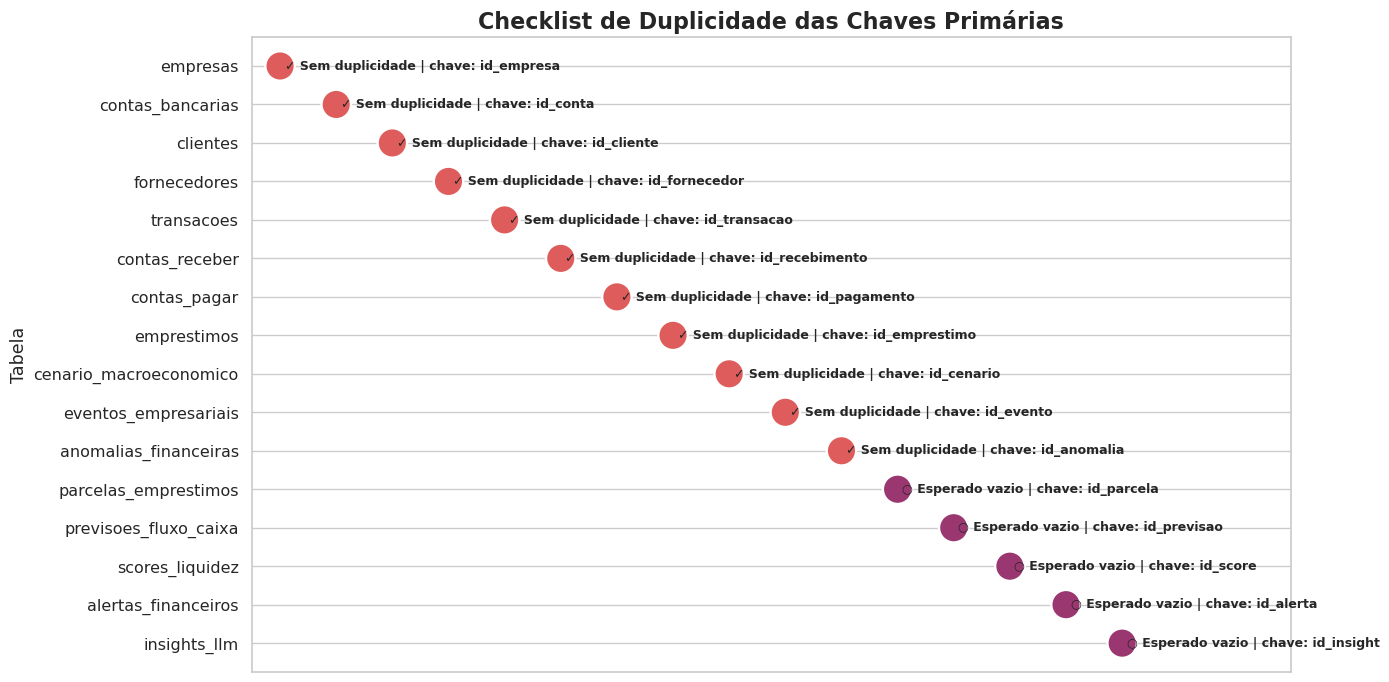

In [24]:
df_check_duplicidades = df_duplicidades.copy()
df_check_duplicidades["ordem"] = range(len(df_check_duplicidades))

df_check_duplicidades["status_visual"] = df_check_duplicidades["status"].map({
    "OK": "✓ Sem duplicidade",
    "Esperado vazio": "○ Esperado vazio",
    "Problema": "✗ Duplicidade encontrada"
})

plt.figure(figsize=(14, 7))

ax = sns.scatterplot(
    data=df_check_duplicidades,
    x="ordem",
    y="tabela",
    hue="status",
    size=[450] * len(df_check_duplicidades),
    sizes=(450, 450),
    palette="flare",
    legend=False
)

for _, row in df_check_duplicidades.iterrows():
    ax.text(
        row["ordem"] + 0.08,
        row["tabela"],
        f"{row['status_visual']} | chave: {row['chave']}",
        va="center",
        fontsize=9,
        weight="bold"
    )

plt.title("Checklist de Duplicidade das Chaves Primárias", fontsize=16, weight="bold")
plt.xlabel("")
plt.ylabel("Tabela")
plt.xticks([])
plt.xlim(-0.5, len(df_check_duplicidades) + 2)
plt.tight_layout()
plt.show()

### Resposta da Pergunta de Negócio 4  
## Existem chaves duplicadas?

A verificação de duplicidade avaliou as principais chaves identificadoras das tabelas do schema `finsight`, incluindo empresas, contas bancárias, clientes, fornecedores, transações, contas a receber, contas a pagar, empréstimos, eventos, anomalias e tabelas analíticas finais.

Não foram encontradas duplicidades nas chaves primárias das tabelas carregadas. Isso indica que os registros possuem identificadores únicos e que as tabelas estão adequadas para operações de relacionamento, agregação e modelagem.

As tabelas analíticas finais aparecem como vazias de forma esperada, pois serão populadas posteriormente pelos notebooks de previsão, score de liquidez, alertas financeiros e insights com LLM.

A ausência de chaves duplicadas reduz o risco de distorções em joins, somatórios financeiros, indicadores de liquidez e criação de features.

Portanto, a base está aprovada no critério de unicidade das chaves.

<div style="background-color: #EAF7EA; padding: 14px; border-left: 5px solid #2E8B57; border-radius: 8px;">

<b>Conclusão:</b>  
Não foram identificadas chaves duplicadas nas tabelas analisadas. A base está consistente para relacionamentos, agregações e criação de features no `02_feature_engineering.ipynb`.

</div>

## 5. O histórico mensal é suficiente para criar lags e médias móveis?

Nesta etapa, avaliamos se cada empresa possui histórico mensal suficiente para a criação de variáveis temporais no notebook `02_feature_engineering.ipynb`.

Essa validação é importante porque features como lags, médias móveis, tendências e volatilidade dependem de uma sequência histórica mínima por empresa.

Serão avaliados:

- quantidade de meses disponíveis por empresa;
- primeiro e último mês com dados;
- saldo total por empresa;
- média mensal de saldo;
- variação mensal do saldo;
- suficiência do histórico para criação de features temporais.

In [25]:
fluxo_mensal = pd.read_sql("""
    SELECT *
    FROM finsight.vw_fluxo_caixa_mensal;
""", engine)

fluxo_mensal.head()

,id_empresa,nome_empresa,setor,porte,mes_referencia,total_entradas,total_saidas,saldo_mes,qtd_transacoes,saldo_medio_diario,saldo_acumulado
0,1,Porto Tech 01,Tecnologia,Média,2023-01-01,217460.81,404763.73,-187302.92,18.0,-15608.576667,-187302.92
1,1,Porto Tech 01,Tecnologia,Média,2023-02-01,207526.04,264659.26,-57133.22,23.0,-4080.944286,-244436.14
2,1,Porto Tech 01,Tecnologia,Média,2023-03-01,269862.64,366060.26,-96197.62,50.0,-4809.881000,-340633.76
3,1,Porto Tech 01,Tecnologia,Média,2023-04-01,511007.83,410198.35,100809.48,45.0,4800.451429,-239824.28
4,1,Porto Tech 01,Tecnologia,Média,2023-05-01,484890.52,465891.98,18998.54,50.0,791.605833,-220825.74


In [26]:
fluxo_mensal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 876 entries, 0 to 875
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_empresa          876 non-null    int64  
 1   nome_empresa        876 non-null    object 
 2   setor               876 non-null    object 
 3   porte               876 non-null    object 
 4   mes_referencia      876 non-null    object 
 5   total_entradas      876 non-null    float64
 6   total_saidas        876 non-null    float64
 7   saldo_mes           876 non-null    float64
 8   qtd_transacoes      876 non-null    float64
 9   saldo_medio_diario  876 non-null    float64
 10  saldo_acumulado     876 non-null    float64
dtypes: float64(6), int64(1), object(4)
memory usage: 75.4+ KB


In [27]:
fluxo_mensal["mes_referencia"] = pd.to_datetime(fluxo_mensal["mes_referencia"])

In [28]:
fluxo_mensal = pd.read_sql("""
    SELECT *
    FROM finsight.vw_fluxo_caixa_mensal;
""", engine)

fluxo_mensal["mes_referencia"] = pd.to_datetime(fluxo_mensal["mes_referencia"])

cobertura_mensal = (
    fluxo_mensal
    .groupby(["id_empresa", "nome_empresa"], as_index=False)
    .agg(
        primeiro_mes=("mes_referencia", "min"),
        ultimo_mes=("mes_referencia", "max"),
        qtd_meses=("mes_referencia", "nunique"),
        saldo_total=("saldo_mes", "sum"),
        media_saldo_mensal=("saldo_mes", "mean"),
        desvio_saldo_mensal=("saldo_mes", "std")
    )
    .sort_values("qtd_meses")
)

def classificar_historico(qtd_meses):
    if qtd_meses >= 24:
        return "Excelente"
    elif qtd_meses >= 12:
        return "Suficiente"
    else:
        return "Atenção"


cobertura_mensal["status_historico"] = cobertura_mensal["qtd_meses"].apply(classificar_historico)

cobertura_mensal

,id_empresa,nome_empresa,primeiro_mes,ultimo_mes,qtd_meses,saldo_total,media_saldo_mensal,desvio_saldo_mensal,status_historico
0,1,Porto Tech 01,2023-01-01,2026-06-01,42,3313535.28,78893.697143,222730.865360,Excelente
17,18,Alves Gestão 18,2023-01-01,2026-06-01,42,2000203.73,47623.898333,156416.102928,Excelente
16,17,Andrade Varejista 17,2023-01-01,2026-06-01,42,3215199.88,76552.378095,229353.598188,Excelente
15,16,Lima Software 16,2023-01-01,2026-06-01,42,4889254.58,116410.823333,305493.958992,Excelente
14,15,Pastor Gastronomia 15,2023-01-01,2026-06-01,42,-87142.28,-2074.816190,245129.006911,Excelente
13,14,Borges Manufatura 14,2023-01-01,2026-06-01,42,1461738.01,34803.285952,157999.516408,Excelente
12,13,Nogueira Serviços 13,2023-01-01,2026-06-01,42,2503952.96,59617.927619,114972.969541,Excelente
10,11,Rocha Alimentos 11,2023-01-01,2026-06-01,42,925777.82,22042.329048,110324.255914,Excelente
9,10,Caldeira Digital 10,2023-01-01,2026-06-01,42,4494944.15,107022.479762,267607.429368,Excelente
7,8,Carvalho Magazine 08,2023-01-01,2026-06-01,42,3644141.26,86765.268095,322483.274613,Excelente


In [29]:
resumo_cobertura = (
    cobertura_mensal
    .groupby("status_historico", as_index=False)
    .agg(
        qtd_empresas=("id_empresa", "count"),
        media_meses=("qtd_meses", "mean"),
        minimo_meses=("qtd_meses", "min"),
        maximo_meses=("qtd_meses", "max")
    )
    .sort_values("qtd_empresas", ascending=False)
)

resumo_cobertura

,status_historico,qtd_empresas,media_meses,minimo_meses,maximo_meses
0,Excelente,20,43.8,42,53


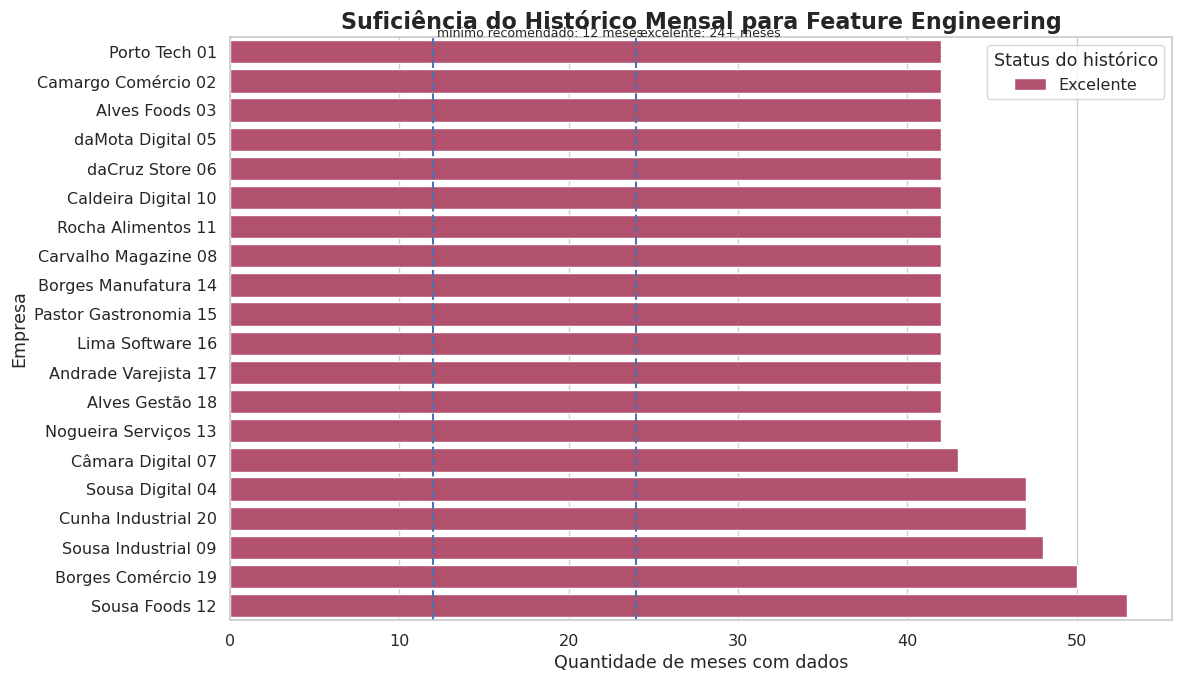

In [30]:
cobertura_plot = cobertura_mensal.sort_values("qtd_meses", ascending=True)

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=cobertura_plot,
    x="qtd_meses",
    y="nome_empresa",
    hue="status_historico",
    palette="flare"
)

ax.axvline(12, linestyle="--", linewidth=1.5)
ax.axvline(24, linestyle="--", linewidth=1.5)

ax.text(12.2, -0.5, "mínimo recomendado: 12 meses", fontsize=9)
ax.text(24.2, -0.5, "excelente: 24+ meses", fontsize=9)

plt.title("Suficiência do Histórico Mensal para Feature Engineering", fontsize=16, weight="bold")
plt.xlabel("Quantidade de meses com dados")
plt.ylabel("Empresa")
plt.legend(title="Status do histórico")
plt.tight_layout()
plt.show()

In [31]:
qtd_empresas_total = cobertura_mensal["id_empresa"].nunique()
qtd_empresas_excelente = (cobertura_mensal["status_historico"] == "Excelente").sum()
qtd_empresas_suficiente = (cobertura_mensal["status_historico"].isin(["Excelente", "Suficiente"])).sum()
qtd_empresas_atencao = (cobertura_mensal["status_historico"] == "Atenção").sum()

menor_historico = cobertura_mensal["qtd_meses"].min()
maior_historico = cobertura_mensal["qtd_meses"].max()
media_historico = cobertura_mensal["qtd_meses"].mean()

diagnostico_historico = pd.DataFrame([
    {
        "indicador": "Total de empresas",
        "valor": qtd_empresas_total
    },
    {
        "indicador": "Empresas com histórico suficiente ou excelente",
        "valor": qtd_empresas_suficiente
    },
    {
        "indicador": "Empresas com histórico excelente",
        "valor": qtd_empresas_excelente
    },
    {
        "indicador": "Empresas com atenção",
        "valor": qtd_empresas_atencao
    },
    {
        "indicador": "Menor quantidade de meses",
        "valor": menor_historico
    },
    {
        "indicador": "Maior quantidade de meses",
        "valor": maior_historico
    },
    {
        "indicador": "Média de meses por empresa",
        "valor": round(media_historico, 2)
    }
])

diagnostico_historico

,indicador,valor
0,Total de empresas,20.0
1,Empresas com histórico suficiente ou excelente,20.0
2,Empresas com histórico excelente,20.0
3,Empresas com atenção,0.0
4,Menor quantidade de meses,42.0
5,Maior quantidade de meses,53.0
6,Média de meses por empresa,43.8


In [32]:
if qtd_empresas_atencao == 0 and menor_historico >= 24:
    print("Histórico excelente: todas as empresas possuem pelo menos 24 meses de dados.")
elif qtd_empresas_atencao == 0 and menor_historico >= 12:
    print("Histórico suficiente: todas as empresas possuem pelo menos 12 meses de dados.")
else:
    print("Atenção: existem empresas com menos de 12 meses de histórico.")

Histórico excelente: todas as empresas possuem pelo menos 24 meses de dados.


In [33]:
teste_lags = fluxo_mensal.sort_values(["id_empresa", "mes_referencia"]).copy()

teste_lags["saldo_mes_lag_1"] = (
    teste_lags
    .groupby("id_empresa")["saldo_mes"]
    .shift(1)
)

teste_lags["saldo_mes_lag_3"] = (
    teste_lags
    .groupby("id_empresa")["saldo_mes"]
    .shift(3)
)

teste_lags["media_movel_saldo_3m"] = (
    teste_lags
    .groupby("id_empresa")["saldo_mes"]
    .transform(lambda x: x.rolling(window=3).mean())
)

teste_lags["media_movel_saldo_6m"] = (
    teste_lags
    .groupby("id_empresa")["saldo_mes"]
    .transform(lambda x: x.rolling(window=6).mean())
)

teste_lags[[
    "id_empresa",
    "nome_empresa",
    "mes_referencia",
    "saldo_mes",
    "saldo_mes_lag_1",
    "saldo_mes_lag_3",
    "media_movel_saldo_3m",
    "media_movel_saldo_6m"
]].head(12)

,id_empresa,nome_empresa,mes_referencia,saldo_mes,saldo_mes_lag_1,saldo_mes_lag_3,media_movel_saldo_3m,media_movel_saldo_6m
0,1,Porto Tech 01,2023-01-01,-187302.92,NaN,NaN,NaN,NaN
1,1,Porto Tech 01,2023-02-01,-57133.22,-187302.92,NaN,NaN,NaN
2,1,Porto Tech 01,2023-03-01,-96197.62,-57133.22,NaN,-113544.586667,NaN
3,1,Porto Tech 01,2023-04-01,100809.48,-96197.62,-187302.92,-17507.120000,NaN
4,1,Porto Tech 01,2023-05-01,18998.54,100809.48,-57133.22,7870.133333,NaN
5,1,Porto Tech 01,2023-06-01,178262.49,18998.54,-96197.62,99356.836667,-7093.875000
6,1,Porto Tech 01,2023-07-01,136744.17,178262.49,100809.48,111335.066667,46913.973333
7,1,Porto Tech 01,2023-08-01,276410.50,136744.17,18998.54,197139.053333,102504.593333
8,1,Porto Tech 01,2023-09-01,137992.80,276410.50,178262.49,183715.823333,141536.330000
9,1,Porto Tech 01,2023-10-01,303405.00,137992.80,136744.17,239269.433333,175302.250000


### Resposta da Pergunta de Negócio 5  
## O histórico mensal é suficiente para criar lags e médias móveis?

A análise de cobertura mensal avaliou a quantidade de meses disponíveis para cada empresa na view `vw_fluxo_caixa_mensal`, que será uma das principais bases para o notebook `02_feature_engineering.ipynb`.

O resultado mostrou que as 20 empresas possuem histórico mensal classificado como excelente. A menor quantidade de meses observada foi de 42 meses, a maior foi de 53 meses, e a média geral foi de 43,8 meses por empresa.

Esse volume temporal é suficiente para a criação de variáveis históricas como lags, médias móveis, volatilidade, tendência e sazonalidade. Na prática, será possível construir atributos como `lag_1`, `lag_3`, `lag_6`, `media_movel_3m`, `media_movel_6m`, `media_movel_12m`, variação percentual mensal e indicadores de comportamento financeiro ao longo do tempo.

Também foi realizado um teste prático de criação de lags e médias móveis sobre o saldo mensal. O teste confirmou que a estrutura dos dados suporta corretamente a criação dessas variáveis por empresa e por mês.

Os valores nulos gerados nas primeiras linhas após a criação dos lags e médias móveis são esperados, pois representam os primeiros meses de cada empresa, nos quais ainda não existe histórico anterior suficiente para cálculo.

Portanto, a base está aprovada no critério de cobertura temporal e está pronta para avançar para a etapa de engenharia de atributos.

<div style="background-color: #EAF7EA; padding: 14px; border-left: 5px solid #2E8B57; border-radius: 8px;">

<b>Conclusão:</b>  
O histórico mensal é excelente para feature engineering. Todas as empresas possuem pelo menos 42 meses de dados, permitindo a criação segura de lags, médias móveis, volatilidade, tendência e variáveis sazonais no `02_feature_engineering.ipynb`.

</div>

## 6. As empresas estão distribuídas por diferentes setores e portes?

Nesta etapa, avaliamos se as empresas da base estão distribuídas de forma adequada entre diferentes setores econômicos e portes empresariais.

Essa validação é importante porque o modelo de previsão de fluxo de caixa e risco de liquidez precisa aprender padrões financeiros variados. Empresas de setores diferentes podem apresentar comportamentos distintos de receita, despesa, sazonalidade, margem e necessidade de capital de giro.

Além disso, o porte da empresa também influencia diretamente o volume financeiro, a estabilidade do caixa e o nível de exposição ao risco.

Serão avaliados:

- quantidade de empresas por setor;
- quantidade de empresas por porte;
- distribuição percentual por setor;
- distribuição percentual por porte;
- combinação entre setor e porte;
- diversidade da base para suportar análises comparativas e modelagem.

In [34]:
df_empresas_analise = dfs_tabelas["empresas"].copy()

df_empresas_analise.columns = df_empresas_analise.columns.str.lower().str.strip()

display(df_empresas_analise.head())

print("Colunas disponíveis na tabela empresas:")
print(df_empresas_analise.columns.tolist())

,id_empresa,nome_empresa,setor,porte,data_abertura,faturamento_medio,quantidade_funcionarios,status,data_criacao
0,1,Porto Tech 01,Tecnologia,Média,2004-04-05,489528.73,72,ativa,2026-06-19 12:43:59.811469
1,2,Camargo Comércio 02,Varejo,Média,2006-12-02,613453.48,155,ativa,2026-06-19 12:43:59.811469
2,3,Alves Foods 03,Alimentação,Média,2004-12-22,376664.06,81,ativa,2026-06-19 12:43:59.811469
3,4,Sousa Digital 04,Tecnologia,Grande,2003-08-08,935137.15,152,ativa,2026-06-19 12:43:59.811469
4,5,daMota Digital 05,Tecnologia,Média,2010-12-25,264907.90,73,ativa,2026-06-19 12:43:59.811469


Colunas disponíveis na tabela empresas:
['id_empresa', 'nome_empresa', 'setor', 'porte', 'data_abertura', 'faturamento_medio', 'quantidade_funcionarios', 'status', 'data_criacao']


In [35]:
coluna_empresa = "id_empresa"
coluna_setor = "setor"
coluna_porte = "porte"

colunas_necessarias = [
    coluna_empresa,
    coluna_setor,
    coluna_porte
]

colunas_ausentes = [
    coluna for coluna in colunas_necessarias
    if coluna not in df_empresas_analise.columns
]

if len(colunas_ausentes) > 0:
    raise ValueError(f"Colunas ausentes na tabela empresas: {colunas_ausentes}")

print("Colunas identificadas com sucesso:")
print(f"Empresa: {coluna_empresa}")
print(f"Setor: {coluna_setor}")
print(f"Porte: {coluna_porte}")

Colunas identificadas com sucesso:
Empresa: id_empresa
Setor: setor
Porte: porte


In [36]:
total_empresas = df_empresas_analise[coluna_empresa].nunique()
qtd_setores = df_empresas_analise[coluna_setor].nunique()
qtd_portes = df_empresas_analise[coluna_porte].nunique()

resumo_distribuicao_empresas = pd.DataFrame({
    "indicador": [
        "Total de empresas",
        "Quantidade de setores",
        "Quantidade de portes"
    ],
    "valor": [
        total_empresas,
        qtd_setores,
        qtd_portes
    ]
})

display(resumo_distribuicao_empresas)

,indicador,valor
0,Total de empresas,20
1,Quantidade de setores,5
2,Quantidade de portes,2


,setor,qtd_empresas,percentual
3,Tecnologia,6,30.0
4,Varejo,5,25.0
0,Alimentação,4,20.0
1,Indústria,3,15.0
2,Serviços,2,10.0


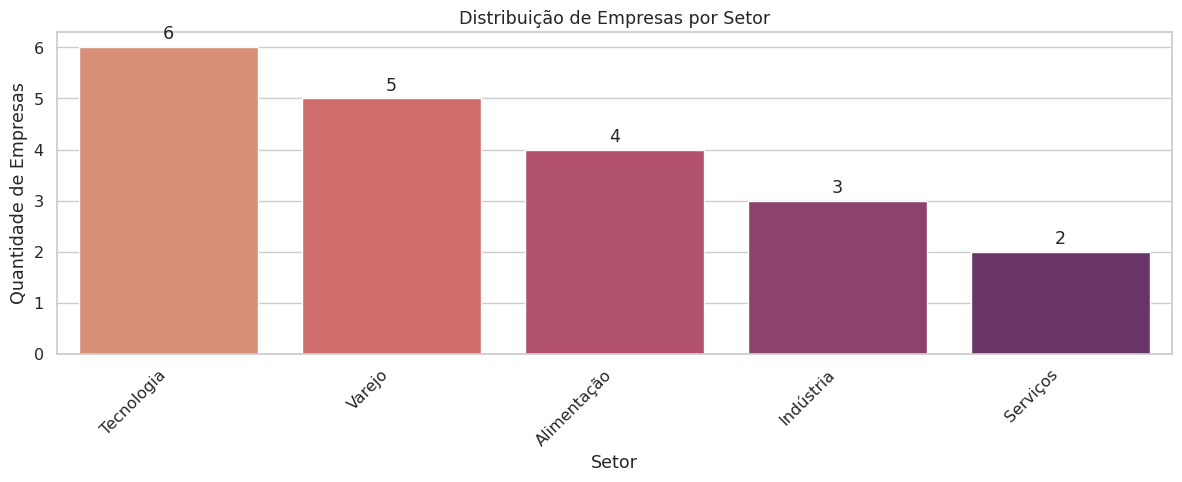

In [37]:
distribuicao_setor = (
    df_empresas_analise
    .groupby(coluna_setor)
    .agg(qtd_empresas=(coluna_empresa, "nunique"))
    .reset_index()
    .sort_values("qtd_empresas", ascending=False)
)

distribuicao_setor["percentual"] = (
    distribuicao_setor["qtd_empresas"] / total_empresas * 100
).round(2)

display(distribuicao_setor)
plt.figure(figsize=(12, 5))

ax = sns.barplot(
    data=distribuicao_setor,
    x=coluna_setor,
    y="qtd_empresas",
    hue=coluna_setor,
    palette="flare",
    legend=False
)

plt.title("Distribuição de Empresas por Setor")
plt.xlabel("Setor")
plt.ylabel("Quantidade de Empresas")
plt.xticks(rotation=45, ha="right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

,setor,porte,qtd_empresas
0,Alimentação,Média,4
4,Tecnologia,Grande,4
7,Varejo,Média,3
2,Indústria,Média,2
3,Serviços,Média,2
5,Tecnologia,Média,2
6,Varejo,Grande,2
1,Indústria,Grande,1


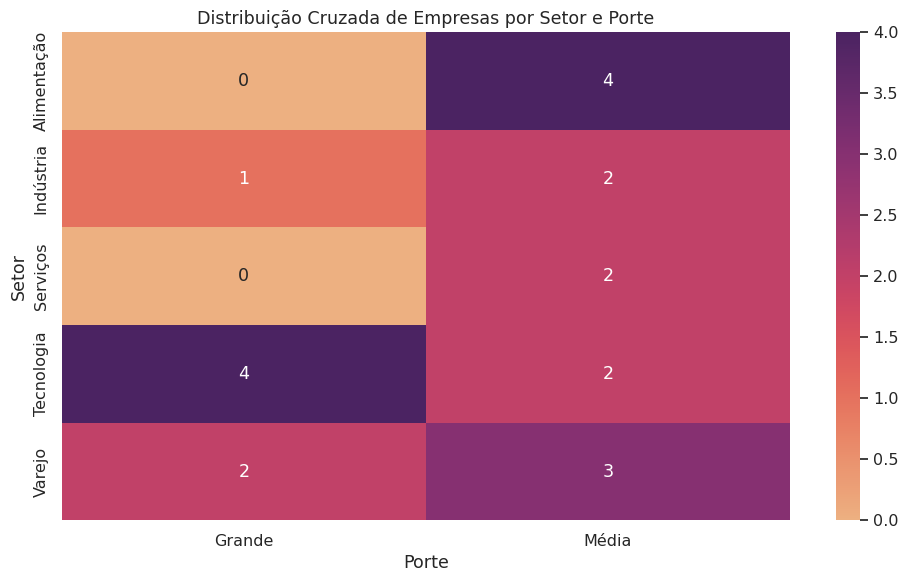

In [38]:
distribuicao_setor_porte = (
    df_empresas_analise
    .groupby([coluna_setor, coluna_porte])
    .agg(qtd_empresas=(coluna_empresa, "nunique"))
    .reset_index()
    .sort_values(
        ["qtd_empresas", coluna_setor, coluna_porte],
        ascending=[False, True, True]
    )
)

display(distribuicao_setor_porte)
tabela_setor_porte = pd.pivot_table(
    distribuicao_setor_porte,
    index=coluna_setor,
    columns=coluna_porte,
    values="qtd_empresas",
    fill_value=0
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    tabela_setor_porte,
    annot=True,
    fmt=".0f",
    cmap="flare"
)

plt.title("Distribuição Cruzada de Empresas por Setor e Porte")
plt.xlabel("Porte")
plt.ylabel("Setor")

plt.tight_layout()
plt.show()

In [39]:
df_empresas_analise = dfs_tabelas["empresas"].copy()
df_empresas_analise.columns = df_empresas_analise.columns.str.lower().str.strip()

coluna_empresa = "id_empresa"
coluna_setor = "setor"
coluna_porte = "porte"

total_empresas = df_empresas_analise[coluna_empresa].nunique()
qtd_setores = df_empresas_analise[coluna_setor].nunique()
qtd_portes = df_empresas_analise[coluna_porte].nunique()

distribuicao_setor = (
    df_empresas_analise
    .groupby(coluna_setor)
    .agg(qtd_empresas=(coluna_empresa, "nunique"))
    .reset_index()
    .sort_values("qtd_empresas", ascending=False)
)

distribuicao_setor["percentual"] = (
    distribuicao_setor["qtd_empresas"] / total_empresas * 100
).round(2)

distribuicao_porte = (
    df_empresas_analise
    .groupby(coluna_porte)
    .agg(qtd_empresas=(coluna_empresa, "nunique"))
    .reset_index()
    .sort_values("qtd_empresas", ascending=False)
)

distribuicao_porte["percentual"] = (
    distribuicao_porte["qtd_empresas"] / total_empresas * 100
).round(2)

distribuicao_setor_porte = (
    df_empresas_analise
    .groupby([coluna_setor, coluna_porte])
    .agg(qtd_empresas=(coluna_empresa, "nunique"))
    .reset_index()
    .sort_values(
        ["qtd_empresas", coluna_setor, coluna_porte],
        ascending=[False, True, True]
    )
)


maior_concentracao_setor = distribuicao_setor["percentual"].max()
maior_concentracao_porte = distribuicao_porte["percentual"].max()

if qtd_setores >= 4 and qtd_portes >= 3 and maior_concentracao_setor <= 50:
    status_diversidade = "Aprovado"
    interpretacao_diversidade = "A base possui boa diversidade entre setores e portes."
elif qtd_setores >= 3 and qtd_portes >= 2:
    status_diversidade = "Atenção"
    interpretacao_diversidade = "A base possui diversidade razoável, mas apresenta alguma concentração."
else:
    status_diversidade = "Revisar"
    interpretacao_diversidade = "A base possui baixa diversidade e pode limitar análises comparativas."

avaliacao_diversidade = pd.DataFrame({
    "indicador": [
        "Total de empresas",
        "Quantidade de setores",
        "Quantidade de portes",
        "Maior concentração por setor (%)",
        "Maior concentração por porte (%)",
        "Status da diversidade",
        "Interpretação"
    ],
    "valor": [
        total_empresas,
        qtd_setores,
        qtd_portes,
        maior_concentracao_setor,
        maior_concentracao_porte,
        status_diversidade,
        interpretacao_diversidade
    ]
})

display(avaliacao_diversidade)

,indicador,valor
0,Total de empresas,20
1,Quantidade de setores,5
2,Quantidade de portes,2
3,Maior concentração por setor (%),30.0
4,Maior concentração por porte (%),65.0
5,Status da diversidade,Atenção
6,Interpretação,"A base possui diversidade razoável, mas aprese..."


## Resposta da Pergunta de Negócio 6

### As empresas estão distribuídas por diferentes setores e portes?

A análise de distribuição avaliou se as empresas cadastradas na tabela `empresas` estão representadas em diferentes setores econômicos e diferentes portes empresariais.

O resultado mostrou que a base possui **20 empresas distribuídas em 5 setores**: Tecnologia, Varejo, Alimentação, Indústria e Serviços. O setor com maior participação é **Tecnologia**, com 6 empresas, representando **30% da base**. Em seguida aparecem Varejo, com 5 empresas, Alimentação, com 4 empresas, Indústria, com 3 empresas, e Serviços, com 2 empresas.

Essa distribuição por setor é positiva, pois evita que a base fique concentrada em apenas um segmento econômico. Com isso, o projeto consegue representar diferentes comportamentos financeiros, como variações de receita, despesas operacionais, sazonalidade, necessidade de capital de giro e exposição ao risco de liquidez.

Na análise por porte, a base possui empresas de **2 portes diferentes**: Grande e Média. A maior concentração está no porte **Média**, que representa **65% das empresas**, enquanto o porte **Grande** representa os 35% restantes.

A distribuição cruzada entre setor e porte mostrou que existe combinação entre diferentes setores e tamanhos de empresa. Porém, nem todos os setores possuem os dois portes representados. Por exemplo, Alimentação e Serviços aparecem apenas com empresas médias, enquanto Tecnologia apresenta maior presença de empresas grandes.

Portanto, a base apresenta boa diversidade setorial, mas possui uma concentração maior em empresas de porte médio. Essa característica não impede a continuidade do projeto, mas deve ser considerada na interpretação das análises e dos modelos, principalmente porque a base não possui empresas de pequeno porte.

<div style="background-color: #EAF7EA; padding: 14px; border-left: 5px solid #2E8B57; border-radius: 8px;">
**Conclusão:**  
A base possui diversidade razoável para análises comparativas e modelagem, com 20 empresas distribuídas em 5 setores diferentes. No entanto, há concentração em empresas de porte médio, que representam 65% da base, e ausência de empresas de pequeno porte. Portanto, a estrutura está aprovada com atenção para seguir no projeto FinSight AI, considerando essa limitação na etapa de modelagem e interpretação dos resultados.

</div>

## 7. O fluxo de caixa possui variação suficiente para modelagem?

Nesta etapa, avaliamos se o fluxo de caixa mensal das empresas apresenta variação suficiente para justificar a criação de modelos preditivos.

Essa validação é importante porque modelos de previsão dependem de oscilações, padrões históricos, tendências e mudanças ao longo do tempo. Se o saldo mensal fosse praticamente constante, haveria pouco comportamento financeiro a ser aprendido pelo modelo.

Serão avaliados:

- média mensal do saldo por empresa;
- desvio padrão do saldo por empresa;
- menor e maior saldo observado;
- amplitude da variação do saldo;
- coeficiente de variação;
- classificação da suficiência da variação para modelagem.

In [40]:
if "vw_fluxo_caixa_mensal" in dfs_tabelas:
    df_fluxo_variacao = dfs_tabelas["vw_fluxo_caixa_mensal"].copy()
else:
    df_fluxo_variacao = pd.read_sql(
        "SELECT * FROM finsight.vw_fluxo_caixa_mensal;",
        engine
    )

df_fluxo_variacao.columns = df_fluxo_variacao.columns.str.lower().str.strip()

display(df_fluxo_variacao.head())

print("Colunas disponíveis na base de fluxo mensal:")
print(df_fluxo_variacao.columns.tolist())

,id_empresa,nome_empresa,setor,porte,mes_referencia,total_entradas,total_saidas,saldo_mes,qtd_transacoes,saldo_medio_diario,saldo_acumulado
0,1,Porto Tech 01,Tecnologia,Média,2023-01-01,217460.81,404763.73,-187302.92,18.0,-15608.576667,-187302.92
1,1,Porto Tech 01,Tecnologia,Média,2023-02-01,207526.04,264659.26,-57133.22,23.0,-4080.944286,-244436.14
2,1,Porto Tech 01,Tecnologia,Média,2023-03-01,269862.64,366060.26,-96197.62,50.0,-4809.881000,-340633.76
3,1,Porto Tech 01,Tecnologia,Média,2023-04-01,511007.83,410198.35,100809.48,45.0,4800.451429,-239824.28
4,1,Porto Tech 01,Tecnologia,Média,2023-05-01,484890.52,465891.98,18998.54,50.0,791.605833,-220825.74


Colunas disponíveis na base de fluxo mensal:
['id_empresa', 'nome_empresa', 'setor', 'porte', 'mes_referencia', 'total_entradas', 'total_saidas', 'saldo_mes', 'qtd_transacoes', 'saldo_medio_diario', 'saldo_acumulado']


In [41]:
coluna_empresa = "id_empresa"
coluna_mes = "mes_referencia"
coluna_saldo = "saldo_acumulado"

colunas_necessarias = [
    coluna_empresa,
    coluna_mes,
    coluna_saldo
]

colunas_ausentes = [
    coluna for coluna in colunas_necessarias
    if coluna not in df_fluxo_variacao.columns
]

if len(colunas_ausentes) > 0:
    raise ValueError(f"Colunas ausentes na view de fluxo mensal: {colunas_ausentes}")

df_fluxo_variacao[coluna_mes] = pd.to_datetime(df_fluxo_variacao[coluna_mes])
df_fluxo_variacao[coluna_saldo] = pd.to_numeric(df_fluxo_variacao[coluna_saldo], errors="coerce")

print("Colunas identificadas com sucesso:")
print(f"Empresa: {coluna_empresa}")
print(f"Mês: {coluna_mes}")
print(f"Saldo mensal: {coluna_saldo}")

Colunas identificadas com sucesso:
Empresa: id_empresa
Mês: mes_referencia
Saldo mensal: saldo_acumulado


In [42]:
resumo_variacao_geral = pd.DataFrame({
    "indicador": [
        "Total de registros mensais",
        "Total de empresas",
        "Total de meses distintos",
        "Saldo acumulado médio geral",
        "Desvio padrão geral",
        "Menor saldo acumulado observado",
        "Maior saldo acumulado observado",
        "Amplitude geral do saldo acumulado"
    ],
    "valor": [
        len(df_fluxo_variacao),
        df_fluxo_variacao[coluna_empresa].nunique(),
        df_fluxo_variacao[coluna_mes].nunique(),
        round(df_fluxo_variacao[coluna_saldo].mean(), 2),
        round(df_fluxo_variacao[coluna_saldo].std(), 2),
        round(df_fluxo_variacao[coluna_saldo].min(), 2),
        round(df_fluxo_variacao[coluna_saldo].max(), 2),
        round(df_fluxo_variacao[coluna_saldo].max() - df_fluxo_variacao[coluna_saldo].min(), 2)
    ]
})

display(resumo_variacao_geral)

,indicador,valor
0,Total de registros mensais,876.00
1,Total de empresas,20.00
2,Total de meses distintos,53.00
3,Saldo acumulado médio geral,943058.99
4,Desvio padrão geral,1601801.59
5,Menor saldo acumulado observado,-2674670.58
6,Maior saldo acumulado observado,7064971.88
7,Amplitude geral do saldo acumulado,9739642.46


In [43]:
variacao_por_empresa = (
    df_fluxo_variacao
    .groupby(coluna_empresa)
    .agg(
        meses_disponiveis=(coluna_mes, "nunique"),
        saldo_acumulado_medio=(coluna_saldo, "mean"),
        desvio_padrao=(coluna_saldo, "std"),
        menor_saldo_acumulado=(coluna_saldo, "min"),
        maior_saldo_acumulado=(coluna_saldo, "max")
    )
    .reset_index()
)

variacao_por_empresa["amplitude_saldo_acumulado"] = (
    variacao_por_empresa["maior_saldo_acumulado"] - variacao_por_empresa["menor_saldo_acumulado"]
)

variacao_por_empresa["coeficiente_variacao_pct"] = (
    variacao_por_empresa["desvio_padrao"] / variacao_por_empresa["saldo_acumulado_medio"].abs() * 100
).round(2)

variacao_por_empresa["saldo_acumulado_medio"] = variacao_por_empresa["saldo_acumulado_medio"].round(2)
variacao_por_empresa["desvio_padrao"] = variacao_por_empresa["desvio_padrao"].round(2)
variacao_por_empresa["menor_saldo_acumulado"] = variacao_por_empresa["menor_saldo_acumulado"].round(2)
variacao_por_empresa["maior_saldo_acumulado"] = variacao_por_empresa["maior_saldo_acumulado"].round(2)
variacao_por_empresa["amplitude_saldo_acumulado"] = variacao_por_empresa["amplitude_saldo_acumulado"].round(2)

display(variacao_por_empresa)

,id_empresa,meses_disponiveis,saldo_acumulado_medio,desvio_padrao,menor_saldo_acumulado,maior_saldo_acumulado,amplitude_saldo_acumulado,coeficiente_variacao_pct
0,1,42,1636855.99,1289857.50,-340633.76,3871481.34,4212115.10,78.80
1,2,42,366224.88,344096.09,-306194.24,929676.52,1235870.76,93.96
2,3,42,12663.00,243558.57,-317571.38,577077.51,894648.89,1923.39
3,4,47,3222109.08,2405328.24,-239513.68,6256601.73,6496115.41,74.65
4,5,42,460390.81,543596.59,-323870.33,1656170.07,1980040.40,118.07
5,6,42,841833.90,834005.78,-254299.48,2560352.74,2814652.22,99.07
6,7,43,4318003.74,2368445.36,-15157.65,7064971.88,7080129.53,54.85
7,8,42,908237.82,1350397.75,-1004356.93,3644141.26,4648498.19,148.68
8,9,48,472351.04,542596.71,-553179.68,1568547.74,2121727.42,114.87
9,10,42,1668108.64,1356157.04,-426735.81,4494944.15,4921679.96,81.30


In [44]:
def classificar_variacao(cv):
    if pd.isna(cv):
        return "Revisar"
    elif cv >= 25:
        return "Variação alta"
    elif cv >= 10:
        return "Variação moderada"
    else:
        return "Variação baixa"

variacao_por_empresa["classificacao_variacao"] = (
    variacao_por_empresa["coeficiente_variacao_pct"]
    .apply(classificar_variacao)
)

resumo_classificacao_variacao = (
    variacao_por_empresa
    .groupby("classificacao_variacao")
    .agg(qtd_empresas=(coluna_empresa, "nunique"))
    .reset_index()
    .sort_values("qtd_empresas", ascending=False)
)

resumo_classificacao_variacao["percentual"] = (
    resumo_classificacao_variacao["qtd_empresas"] / variacao_por_empresa[coluna_empresa].nunique() * 100
).round(2)

display(resumo_classificacao_variacao)

,classificacao_variacao,qtd_empresas,percentual
0,Variação alta,20,100.0


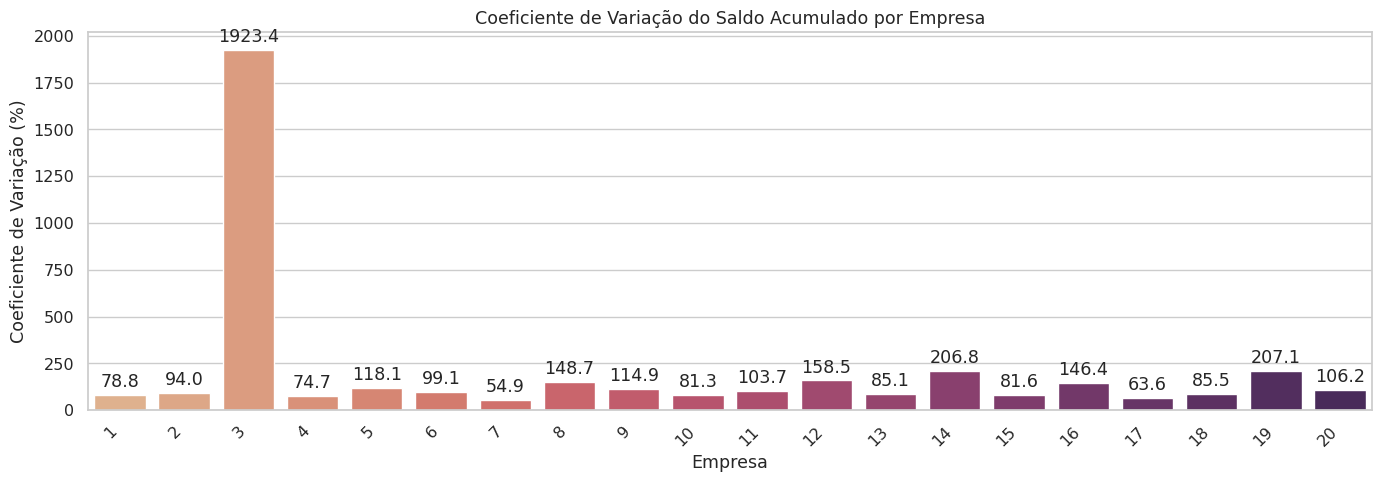

In [45]:
plt.figure(figsize=(14, 5))

ax = sns.barplot(
    data=variacao_por_empresa.sort_values("coeficiente_variacao_pct", ascending=False),
    x=coluna_empresa,
    y="coeficiente_variacao_pct",
    hue=coluna_empresa,
    palette="flare",
    legend=False
)

plt.title("Coeficiente de Variação do Saldo Acumulado por Empresa")
plt.xlabel("Empresa")
plt.ylabel("Coeficiente de Variação (%)")
plt.xticks(rotation=45, ha="right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3)

plt.tight_layout()
plt.show()

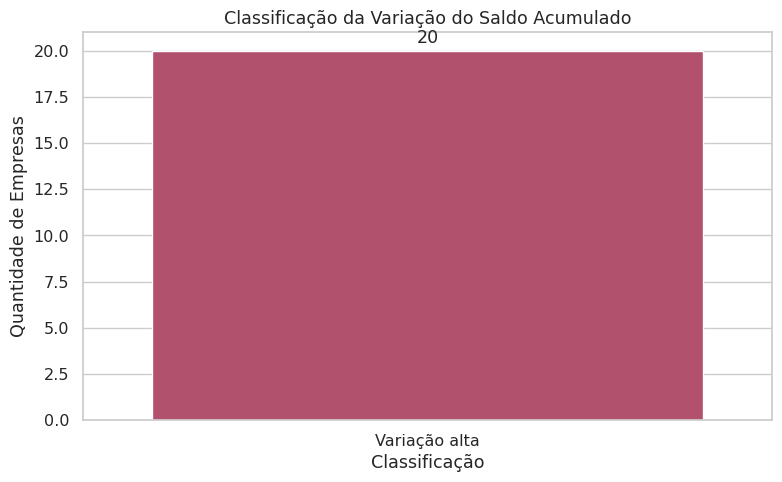

In [46]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=resumo_classificacao_variacao,
    x="classificacao_variacao",
    y="qtd_empresas",
    hue="classificacao_variacao",
    palette="flare",
    legend=False
)

plt.title("Classificação da Variação do Saldo Acumulado")
plt.xlabel("Classificação")
plt.ylabel("Quantidade de Empresas")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

## Resposta da Pergunta de Negócio 7

### O fluxo de caixa possui variação suficiente para modelagem?

A análise de variação avaliou se o `saldo_acumulado` mensal das empresas apresenta oscilação suficiente para justificar a criação de modelos preditivos no projeto FinSight AI.

O resultado mostrou que a base possui **876 registros mensais**, contemplando **20 empresas** ao longo de **53 meses distintos**. O saldo acumulado médio geral foi de **943.058,99**, com desvio padrão de **1.601.801,59**, indicando uma dispersão relevante dos valores ao longo do tempo.

Também foi observada uma amplitude geral expressiva no saldo acumulado. O menor saldo acumulado registrado foi de **-2.674.670,58**, enquanto o maior saldo acumulado observado foi de **7.064.971,88**, resultando em uma amplitude total de **9.739.642,46**. Essa diferença mostra que a base possui forte variação financeira entre empresas e períodos.

Na análise por empresa, todas as 20 empresas apresentaram coeficiente de variação classificado como **variação alta**. O menor coeficiente de variação observado foi de **54,85%**, enquanto o maior chegou a **1.923,39%**. Isso confirma que o saldo acumulado não se mantém estático e possui oscilações relevantes para o aprendizado de padrões temporais.

Essa variação é positiva para a modelagem, pois permite que algoritmos identifiquem tendências, mudanças de comportamento, períodos de maior pressão de caixa, recuperação financeira e possíveis sinais de risco de liquidez. Na prática, a base apresenta comportamento suficiente para criação de modelos de previsão e indicadores derivados.

Portanto, a base está aprovada no critério de variação do fluxo de caixa e pode seguir para as próximas etapas de engenharia de atributos e modelagem preditiva.

<div style="background-color:#e8f5e9; border-left:5px solid #2e7d32; padding:12px; border-radius:6px;">

**Conclusão:**  
O fluxo de caixa possui variação excelente para modelagem. Todas as 20 empresas apresentaram variação alta no `saldo_acumulado`, com amplitude geral de 9.739.642,46 e coeficientes de variação relevantes ao longo do histórico mensal. Portanto, a base está aprovada para criação de modelos preditivos, features temporais e indicadores de risco de liquidez no projeto FinSight AI.

</div>

## 8. Existem contas a receber vencidas ou em aberto?

Nesta etapa, avaliamos a situação das contas a receber para identificar valores ainda não recebidos e títulos vencidos.

Essa validação é importante porque contas a receber em aberto representam entradas futuras de caixa, enquanto contas vencidas indicam risco de inadimplência, atraso no recebimento e possível pressão sobre a liquidez da empresa.

Serão avaliados:

- quantidade total de contas a receber;
- quantidade de contas recebidas, em aberto e vencidas;
- valor total a receber;
- valor em aberto;
- valor vencido;
- percentual financeiro em aberto;
- percentual financeiro vencido;
- distribuição das contas vencidas por empresa.

In [50]:
if "contas_receber" in dfs_tabelas:
    df_receber = dfs_tabelas["contas_receber"].copy()
else:
    df_receber = pd.read_sql(
        "SELECT * FROM finsight.contas_receber;",
        engine
    )

df_receber.columns = df_receber.columns.str.lower().str.strip()

display(df_receber.head())

print("Colunas disponíveis na tabela contas_receber:")
print(df_receber.columns.tolist())

,id_recebimento,id_empresa,id_cliente,data_emissao,data_vencimento,data_pagamento,valor,status,dias_atraso,data_criacao
0,1,1,6,2023-01-26,2023-03-27,2023-03-30,669.40,paga,3,2026-06-19 12:43:59.859029
1,2,1,52,2023-01-25,2023-02-01,2023-01-30,16750.57,paga,0,2026-06-19 12:43:59.859029
2,3,1,50,2023-01-03,2023-01-10,2023-01-16,12440.94,paga,6,2026-06-19 12:43:59.859029
3,4,1,10,2023-01-19,2023-03-20,2023-03-20,941.30,paga,0,2026-06-19 12:43:59.859029
4,5,1,40,2023-01-04,2023-01-11,2023-01-09,5817.35,paga,0,2026-06-19 12:43:59.859029


Colunas disponíveis na tabela contas_receber:
['id_recebimento', 'id_empresa', 'id_cliente', 'data_emissao', 'data_vencimento', 'data_pagamento', 'valor', 'status', 'dias_atraso', 'data_criacao']


In [51]:
def encontrar_coluna(possibilidades, colunas):
    for coluna in possibilidades:
        if coluna in colunas:
            return coluna
    return None

coluna_empresa = encontrar_coluna(
    ["id_empresa", "empresa_id"],
    df_receber.columns
)

coluna_valor = encontrar_coluna(
    ["valor", "valor_original", "valor_conta", "valor_receber", "valor_titulo"],
    df_receber.columns
)

coluna_vencimento = encontrar_coluna(
    ["data_vencimento", "dt_vencimento", "vencimento"],
    df_receber.columns
)

coluna_recebimento = encontrar_coluna(
    ["data_recebimento", "dt_recebimento", "data_pagamento", "dt_pagamento"],
    df_receber.columns
)

coluna_status = encontrar_coluna(
    ["status", "status_recebimento", "situacao"],
    df_receber.columns
)

colunas_necessarias = [
    coluna_empresa,
    coluna_valor,
    coluna_vencimento
]

if any(coluna is None for coluna in colunas_necessarias):
    raise ValueError("Não foi possível identificar as colunas mínimas de empresa, valor e vencimento.")

df_receber[coluna_valor] = pd.to_numeric(df_receber[coluna_valor], errors="coerce")
df_receber[coluna_vencimento] = pd.to_datetime(df_receber[coluna_vencimento])

if coluna_recebimento is not None:
    df_receber[coluna_recebimento] = pd.to_datetime(df_receber[coluna_recebimento], errors="coerce")

print("Colunas identificadas com sucesso:")
print(f"Empresa: {coluna_empresa}")
print(f"Valor: {coluna_valor}")
print(f"Vencimento: {coluna_vencimento}")
print(f"Recebimento: {coluna_recebimento}")
print(f"Status: {coluna_status}")

Colunas identificadas com sucesso:
Empresa: id_empresa
Valor: valor
Vencimento: data_vencimento
Recebimento: data_pagamento
Status: status


In [52]:
data_referencia = df_receber[coluna_vencimento].max()

if coluna_status is not None:
    status_normalizado = (
        df_receber[coluna_status]
        .astype(str)
        .str.lower()
        .str.strip()
    )
else:
    status_normalizado = pd.Series([""] * len(df_receber), index=df_receber.index)

if coluna_recebimento is not None:
    conta_recebida = df_receber[coluna_recebimento].notna()
else:
    conta_recebida = status_normalizado.str.contains("receb|pago|liquid", regex=True)

df_receber["situacao_recebimento"] = "Em aberto"

df_receber.loc[
    conta_recebida,
    "situacao_recebimento"
] = "Recebida"

df_receber.loc[
    (df_receber["situacao_recebimento"] == "Em aberto") &
    (df_receber[coluna_vencimento] < data_referencia),
    "situacao_recebimento"
] = "Vencida"

display(df_receber.head())
print(f"Data de referência da análise: {data_referencia.date()}")

,id_recebimento,id_empresa,id_cliente,data_emissao,data_vencimento,data_pagamento,valor,status,dias_atraso,data_criacao,situacao_recebimento
0,1,1,6,2023-01-26,2023-03-27,2023-03-30,669.40,paga,3,2026-06-19 12:43:59.859029,Recebida
1,2,1,52,2023-01-25,2023-02-01,2023-01-30,16750.57,paga,0,2026-06-19 12:43:59.859029,Recebida
2,3,1,50,2023-01-03,2023-01-10,2023-01-16,12440.94,paga,6,2026-06-19 12:43:59.859029,Recebida
3,4,1,10,2023-01-19,2023-03-20,2023-03-20,941.30,paga,0,2026-06-19 12:43:59.859029,Recebida
4,5,1,40,2023-01-04,2023-01-11,2023-01-09,5817.35,paga,0,2026-06-19 12:43:59.859029,Recebida


Data de referência da análise: 2026-08-16


In [53]:
resumo_contas_receber = (
    df_receber
    .groupby("situacao_recebimento")
    .agg(
        qtd_contas=(coluna_valor, "count"),
        valor_total=(coluna_valor, "sum")
    )
    .reset_index()
    .sort_values("valor_total", ascending=False)
)

valor_total_receber = df_receber[coluna_valor].sum()

resumo_contas_receber["percentual_financeiro"] = (
    resumo_contas_receber["valor_total"] / valor_total_receber * 100
).round(2)

resumo_contas_receber["valor_total"] = resumo_contas_receber["valor_total"].round(2)

display(resumo_contas_receber)

,situacao_recebimento,qtd_contas,valor_total,percentual_financeiro
1,Recebida,66227,5.552426e+08,96.05
2,Vencida,2734,2.272568e+07,3.93
0,Em aberto,15,1.133819e+05,0.02


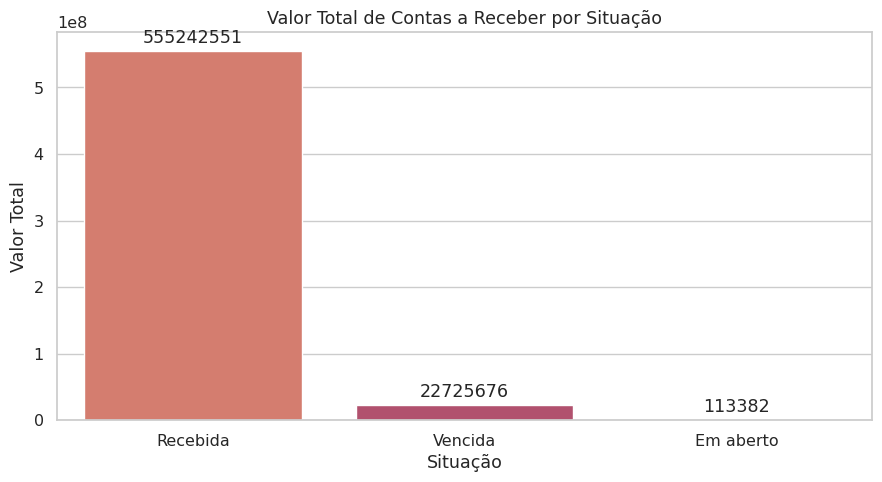

In [54]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=resumo_contas_receber,
    x="situacao_recebimento",
    y="valor_total",
    hue="situacao_recebimento",
    palette="flare",
    legend=False
)

plt.title("Valor Total de Contas a Receber por Situação")
plt.xlabel("Situação")
plt.ylabel("Valor Total")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

In [55]:
contas_vencidas_empresa = (
    df_receber[df_receber["situacao_recebimento"] == "Vencida"]
    .groupby(coluna_empresa)
    .agg(
        qtd_contas_vencidas=(coluna_valor, "count"),
        valor_vencido=(coluna_valor, "sum")
    )
    .reset_index()
    .sort_values("valor_vencido", ascending=False)
)

contas_vencidas_empresa["valor_vencido"] = contas_vencidas_empresa["valor_vencido"].round(2)

display(contas_vencidas_empresa)

,id_empresa,qtd_contas_vencidas,valor_vencido
15,16,182,1740068.92
7,8,127,1699438.51
9,10,190,1605902.71
1,2,246,1596782.24
16,17,311,1551299.36
8,9,253,1542553.81
5,6,153,1518387.05
14,15,119,1359588.84
18,19,137,1191924.68
0,1,84,1172278.53


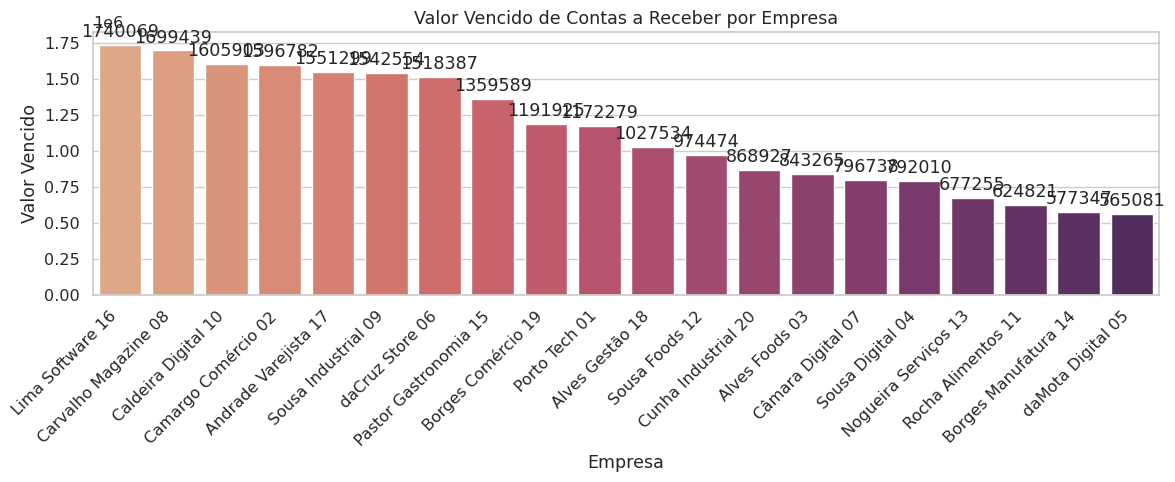

In [62]:
df_empresas_nome = dfs_tabelas["empresas"].copy()
df_empresas_nome.columns = df_empresas_nome.columns.str.lower().str.strip()

contas_vencidas_empresa = contas_vencidas_empresa.merge(
    df_empresas_nome[["id_empresa", "nome_empresa"]],
    on="id_empresa",
    how="left"
)
plt.figure(figsize=(12, 5))

ax = sns.barplot(
    data=contas_vencidas_empresa,
    x="nome_empresa",
    y="valor_vencido",
    hue="nome_empresa",
    palette="flare",
    legend=False
)

plt.title("Valor Vencido de Contas a Receber por Empresa")
plt.xlabel("Empresa")
plt.ylabel("Valor Vencido")
plt.xticks(rotation=45, ha="right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

In [63]:
if percentual_vencido <= 10 and percentual_em_aberto <= 40:
    status_contas_receber = "Aprovado"
    interpretacao_contas_receber = "A base possui nível controlado de contas vencidas e em aberto."
elif percentual_vencido <= 25:
    status_contas_receber = "Atenção"
    interpretacao_contas_receber = "A base possui presença relevante de contas vencidas ou em aberto."
else:
    status_contas_receber = "Revisar"
    interpretacao_contas_receber = "A base possui alta concentração financeira em contas vencidas."

avaliacao_contas_receber = pd.DataFrame({
    "indicador": [
        "Valor total a receber",
        "Valor em aberto",
        "Valor vencido",
        "Percentual financeiro em aberto (%)",
        "Percentual financeiro vencido (%)",
        "Status das contas a receber",
        "Interpretação"
    ],
    "valor": [
        round(valor_total, 2),
        round(valor_em_aberto, 2),
        round(valor_vencido, 2),
        percentual_em_aberto,
        percentual_vencido,
        status_contas_receber,
        interpretacao_contas_receber
    ]
})

display(avaliacao_contas_receber)

,indicador,valor
0,Valor total a receber,578081609.11
1,Valor em aberto,113381.86
2,Valor vencido,22725676.49
3,Percentual financeiro em aberto (%),0.02
4,Percentual financeiro vencido (%),3.93
5,Status das contas a receber,Aprovado
6,Interpretação,A base possui nível controlado de contas venci...


## Resposta da Pergunta de Negócio 8

### Existem contas a receber vencidas ou em aberto?

A análise das contas a receber avaliou a situação dos títulos registrados na tabela `contas_receber`, com foco na identificação de valores recebidos, vencidos e ainda em aberto.

O resultado mostrou que a maior parte do valor financeiro está concentrada em contas já recebidas. O valor total analisado foi de **578.081.609,11**, sendo **555.242.551,00** classificados como recebidos, o que representa **96,05%** do total financeiro da base.

Também foram identificadas contas vencidas, somando **22.725.676,49**, equivalente a **3,93%** do valor total a receber. Apesar de existir volume vencido, o percentual financeiro é relativamente baixo em relação ao total da carteira, indicando que o risco de inadimplência está presente, mas em nível controlado.

As contas em aberto representam apenas **113.381,86**, o equivalente a **0,02%** do total financeiro. Isso mostra que quase todo o fluxo previsto de recebimento já foi liquidado ou está classificado como vencido, com baixa concentração em valores ainda aguardando vencimento ou recebimento futuro.

Na análise por empresa, todas as empresas possuem algum valor vencido, mas os maiores volumes estão concentrados em empresas específicas, como **Lima Software 16**, **Carvalho Magazine 08**, **Caldeira Digital 10**, **Camargo Comércio 02** e **Andrade Varejista 17**. Esses casos merecem atenção em análises futuras de risco de liquidez, pois podem indicar maior exposição a atrasos de recebimento.

Portanto, a base está aprovada no critério de contas a receber. Existem contas vencidas e em aberto, mas o percentual financeiro vencido é baixo em relação ao total, e o valor em aberto é praticamente residual.

<div style="background-color:#e8f5e9; border-left:5px solid #2e7d32; padding:12px; border-radius:6px;">

**Conclusão:**  
A carteira de contas a receber apresenta situação controlada. Do total de **578.081.609,11**, aproximadamente **96,05%** já foi recebido, enquanto **3,93%** está vencido e apenas **0,02%** permanece em aberto. Apesar da existência de contas vencidas em todas as empresas, o volume proporcional é baixo, permitindo seguir com a base para análises de liquidez, inadimplência e modelagem de risco no projeto FinSight AI.

</div>

## 9. Existem contas a pagar vencidas ou em aberto?

Nesta etapa, avaliamos a situação das contas a pagar para identificar obrigações financeiras já pagas, ainda em aberto ou vencidas.

Essa validação é importante porque contas a pagar em aberto representam saídas futuras de caixa, enquanto contas vencidas indicam atraso no cumprimento de obrigações financeiras. Esse comportamento pode sinalizar pressão de liquidez, dificuldade de pagamento ou maior risco operacional.

Serão avaliados:

- quantidade total de contas a pagar;
- quantidade de contas pagas, em aberto e vencidas;
- valor total a pagar;
- valor pago;
- valor em aberto;
- valor vencido;
- percentual financeiro em aberto;
- percentual financeiro vencido;
- distribuição das contas vencidas por empresa.

In [64]:
if "contas_pagar" in dfs_tabelas:
    df_pagar = dfs_tabelas["contas_pagar"].copy()
else:
    df_pagar = pd.read_sql(
        "SELECT * FROM finsight.contas_pagar;",
        engine
    )

df_pagar.columns = df_pagar.columns.str.lower().str.strip()

display(df_pagar.head())

print("Colunas disponíveis na tabela contas_pagar:")
print(df_pagar.columns.tolist())

,id_pagamento,id_empresa,id_fornecedor,data_emissao,data_vencimento,data_pagamento,valor,categoria,status,data_criacao
0,1,1,12,2023-01-04,2023-01-19,2023-01-20,136341.47,Folha de Pagamento,paga,2026-06-19 12:44:01.249225
1,2,1,19,2023-01-09,2023-01-24,2023-01-24,68170.73,Impostos,paga,2026-06-19 12:44:01.249225
2,3,1,16,2023-01-04,2023-01-19,2023-01-21,34085.37,Aluguel,paga,2026-06-19 12:44:01.249225
3,4,1,2,2023-01-09,2023-02-08,2023-02-09,21303.35,Tecnologia,paga,2026-06-19 12:44:01.249225
4,5,1,1,2023-01-09,2023-01-16,2023-01-16,25564.03,Marketing,paga,2026-06-19 12:44:01.249225


Colunas disponíveis na tabela contas_pagar:
['id_pagamento', 'id_empresa', 'id_fornecedor', 'data_emissao', 'data_vencimento', 'data_pagamento', 'valor', 'categoria', 'status', 'data_criacao']


In [65]:
def encontrar_coluna(possibilidades, colunas):
    for coluna in possibilidades:
        if coluna in colunas:
            return coluna
    return None

coluna_empresa = encontrar_coluna(
    ["id_empresa", "empresa_id"],
    df_pagar.columns
)

coluna_valor = encontrar_coluna(
    ["valor", "valor_original", "valor_conta", "valor_pagar", "valor_titulo"],
    df_pagar.columns
)

coluna_vencimento = encontrar_coluna(
    ["data_vencimento", "dt_vencimento", "vencimento"],
    df_pagar.columns
)

coluna_pagamento = encontrar_coluna(
    ["data_pagamento", "dt_pagamento", "data_liquidacao", "dt_liquidacao"],
    df_pagar.columns
)

coluna_status = encontrar_coluna(
    ["status", "status_pagamento", "situacao"],
    df_pagar.columns
)

colunas_necessarias = [
    coluna_empresa,
    coluna_valor,
    coluna_vencimento
]

if any(coluna is None for coluna in colunas_necessarias):
    raise ValueError("Não foi possível identificar as colunas mínimas de empresa, valor e vencimento.")

df_pagar[coluna_valor] = pd.to_numeric(df_pagar[coluna_valor], errors="coerce")
df_pagar[coluna_vencimento] = pd.to_datetime(df_pagar[coluna_vencimento])

if coluna_pagamento is not None:
    df_pagar[coluna_pagamento] = pd.to_datetime(df_pagar[coluna_pagamento], errors="coerce")

print("Colunas identificadas com sucesso:")
print(f"Empresa: {coluna_empresa}")
print(f"Valor: {coluna_valor}")
print(f"Vencimento: {coluna_vencimento}")
print(f"Pagamento: {coluna_pagamento}")
print(f"Status: {coluna_status}")

Colunas identificadas com sucesso:
Empresa: id_empresa
Valor: valor
Vencimento: data_vencimento
Pagamento: data_pagamento
Status: status


In [66]:
data_referencia = df_pagar[coluna_vencimento].max()

if coluna_status is not None:
    status_normalizado = (
        df_pagar[coluna_status]
        .astype(str)
        .str.lower()
        .str.strip()
    )
else:
    status_normalizado = pd.Series([""] * len(df_pagar), index=df_pagar.index)

if coluna_pagamento is not None:
    conta_paga = df_pagar[coluna_pagamento].notna()
else:
    conta_paga = status_normalizado.str.contains("pago|paga|liquid", regex=True)

df_pagar["situacao_pagamento"] = "Em aberto"

df_pagar.loc[
    conta_paga,
    "situacao_pagamento"
] = "Paga"

df_pagar.loc[
    (df_pagar["situacao_pagamento"] == "Em aberto") &
    (df_pagar[coluna_vencimento] < data_referencia),
    "situacao_pagamento"
] = "Vencida"

display(df_pagar.head())
print(f"Data de referência da análise: {data_referencia.date()}")

,id_pagamento,id_empresa,id_fornecedor,data_emissao,data_vencimento,data_pagamento,valor,categoria,status,data_criacao,situacao_pagamento
0,1,1,12,2023-01-04,2023-01-19,2023-01-20,136341.47,Folha de Pagamento,paga,2026-06-19 12:44:01.249225,Paga
1,2,1,19,2023-01-09,2023-01-24,2023-01-24,68170.73,Impostos,paga,2026-06-19 12:44:01.249225,Paga
2,3,1,16,2023-01-04,2023-01-19,2023-01-21,34085.37,Aluguel,paga,2026-06-19 12:44:01.249225,Paga
3,4,1,2,2023-01-09,2023-02-08,2023-02-09,21303.35,Tecnologia,paga,2026-06-19 12:44:01.249225,Paga
4,5,1,1,2023-01-09,2023-01-16,2023-01-16,25564.03,Marketing,paga,2026-06-19 12:44:01.249225,Paga


Data de referência da análise: 2026-07-25


In [67]:
resumo_contas_pagar = (
    df_pagar
    .groupby("situacao_pagamento")
    .agg(
        qtd_contas=(coluna_valor, "count"),
        valor_total=(coluna_valor, "sum")
    )
    .reset_index()
    .sort_values("valor_total", ascending=False)
)

valor_total_pagar = df_pagar[coluna_valor].sum()

resumo_contas_pagar["percentual_financeiro"] = (
    resumo_contas_pagar["valor_total"] / valor_total_pagar * 100
).round(2)

resumo_contas_pagar["valor_total"] = resumo_contas_pagar["valor_total"].round(2)

display(resumo_contas_pagar)

,situacao_pagamento,qtd_contas,valor_total,percentual_financeiro
1,Paga,8208,5.047235e+08,97.53
2,Vencida,186,1.253185e+07,2.42
0,Em aberto,6,2.748586e+05,0.05


In [68]:
total_contas = len(df_pagar)
total_pagas = df_pagar[df_pagar["situacao_pagamento"] == "Paga"].shape[0]
total_em_aberto = df_pagar[df_pagar["situacao_pagamento"] == "Em aberto"].shape[0]
total_vencidas = df_pagar[df_pagar["situacao_pagamento"] == "Vencida"].shape[0]

valor_total = df_pagar[coluna_valor].sum()
valor_pago = df_pagar.loc[df_pagar["situacao_pagamento"] == "Paga", coluna_valor].sum()
valor_em_aberto = df_pagar.loc[df_pagar["situacao_pagamento"] == "Em aberto", coluna_valor].sum()
valor_vencido = df_pagar.loc[df_pagar["situacao_pagamento"] == "Vencida", coluna_valor].sum()

percentual_em_aberto = round(valor_em_aberto / valor_total * 100, 2)
percentual_vencido = round(valor_vencido / valor_total * 100, 2)

indicadores_contas_pagar = pd.DataFrame({
    "indicador": [
        "Total de contas a pagar",
        "Contas pagas",
        "Contas em aberto",
        "Contas vencidas",
        "Valor total a pagar",
        "Valor pago",
        "Valor em aberto",
        "Valor vencido",
        "Percentual financeiro em aberto (%)",
        "Percentual financeiro vencido (%)"
    ],
    "valor": [
        total_contas,
        total_pagas,
        total_em_aberto,
        total_vencidas,
        round(valor_total, 2),
        round(valor_pago, 2),
        round(valor_em_aberto, 2),
        round(valor_vencido, 2),
        percentual_em_aberto,
        percentual_vencido
    ]
})

display(indicadores_contas_pagar)

,indicador,valor
0,Total de contas a pagar,8.400000e+03
1,Contas pagas,8.208000e+03
2,Contas em aberto,6.000000e+00
3,Contas vencidas,1.860000e+02
4,Valor total a pagar,5.175302e+08
5,Valor pago,5.047235e+08
6,Valor em aberto,2.748586e+05
7,Valor vencido,1.253185e+07
8,Percentual financeiro em aberto (%),5.000000e-02
9,Percentual financeiro vencido (%),2.420000e+00


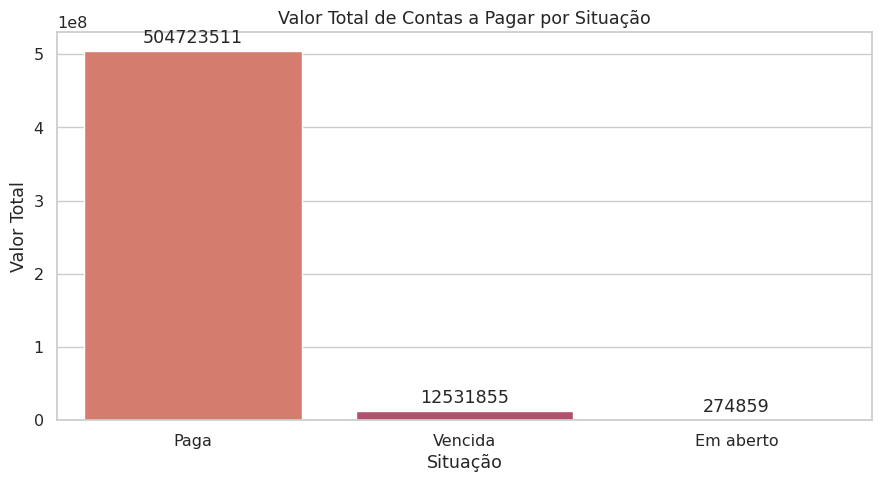

In [69]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=resumo_contas_pagar,
    x="situacao_pagamento",
    y="valor_total",
    hue="situacao_pagamento",
    palette="flare",
    legend=False
)

plt.title("Valor Total de Contas a Pagar por Situação")
plt.xlabel("Situação")
plt.ylabel("Valor Total")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

In [70]:
contas_vencidas_pagar_empresa = (
    df_pagar[df_pagar["situacao_pagamento"] == "Vencida"]
    .groupby(coluna_empresa)
    .agg(
        qtd_contas_vencidas=(coluna_valor, "count"),
        valor_vencido=(coluna_valor, "sum")
    )
    .reset_index()
    .sort_values("valor_vencido", ascending=False)
)

contas_vencidas_pagar_empresa["valor_vencido"] = contas_vencidas_pagar_empresa["valor_vencido"].round(2)

df_empresas_nome = dfs_tabelas["empresas"].copy()
df_empresas_nome.columns = df_empresas_nome.columns.str.lower().str.strip()

contas_vencidas_pagar_empresa = contas_vencidas_pagar_empresa.merge(
    df_empresas_nome[["id_empresa", "nome_empresa"]],
    on="id_empresa",
    how="left"
)

display(contas_vencidas_pagar_empresa)

,id_empresa,qtd_contas_vencidas,valor_vencido,nome_empresa
0,10,11,1430254.97,Caldeira Digital 10
1,17,9,968581.21,Andrade Varejista 17
2,15,11,967208.72,Pastor Gastronomia 15
3,19,9,955187.83,Borges Comércio 19
4,2,9,869657.92,Camargo Comércio 02
5,12,11,868591.17,Sousa Foods 12
6,8,7,753803.18,Carvalho Magazine 08
7,9,10,724876.20,Sousa Industrial 09
8,6,9,653721.49,daCruz Store 06
9,1,7,536940.77,Porto Tech 01


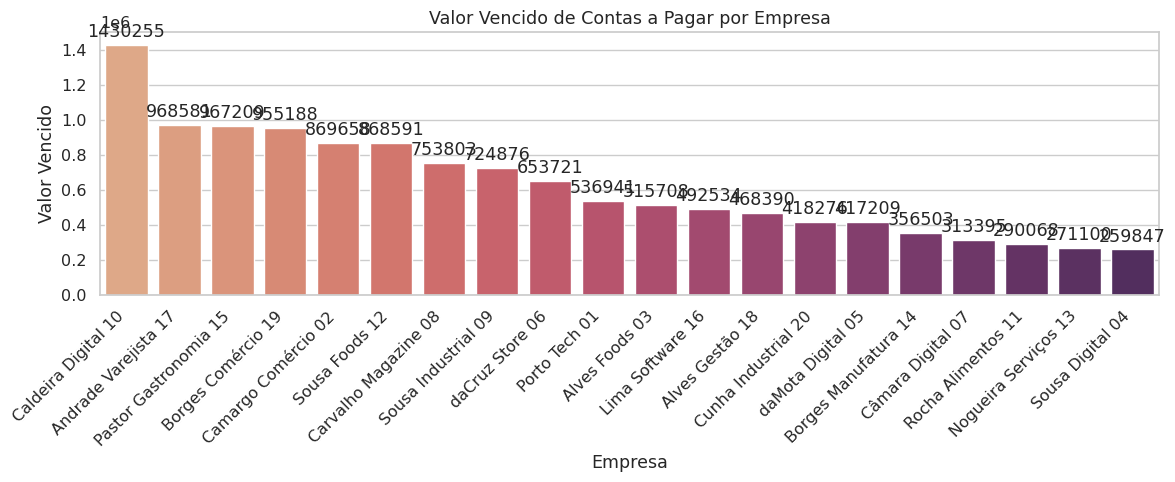

In [71]:
plt.figure(figsize=(12, 5))

ax = sns.barplot(
    data=contas_vencidas_pagar_empresa,
    x="nome_empresa",
    y="valor_vencido",
    hue="nome_empresa",
    palette="flare",
    legend=False
)

plt.title("Valor Vencido de Contas a Pagar por Empresa")
plt.xlabel("Empresa")
plt.ylabel("Valor Vencido")
plt.xticks(rotation=45, ha="right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

In [72]:
if percentual_vencido <= 10 and percentual_em_aberto <= 40:
    status_contas_pagar = "Aprovado"
    interpretacao_contas_pagar = "A base possui nível controlado de contas vencidas e em aberto."
elif percentual_vencido <= 25:
    status_contas_pagar = "Atenção"
    interpretacao_contas_pagar = "A base possui presença relevante de contas vencidas ou em aberto."
else:
    status_contas_pagar = "Revisar"
    interpretacao_contas_pagar = "A base possui alta concentração financeira em contas vencidas."

avaliacao_contas_pagar = pd.DataFrame({
    "indicador": [
        "Valor total a pagar",
        "Valor em aberto",
        "Valor vencido",
        "Percentual financeiro em aberto (%)",
        "Percentual financeiro vencido (%)",
        "Status das contas a pagar",
        "Interpretação"
    ],
    "valor": [
        round(valor_total, 2),
        round(valor_em_aberto, 2),
        round(valor_vencido, 2),
        percentual_em_aberto,
        percentual_vencido,
        status_contas_pagar,
        interpretacao_contas_pagar
    ]
})

display(avaliacao_contas_pagar)

,indicador,valor
0,Valor total a pagar,517530224.41
1,Valor em aberto,274858.6
2,Valor vencido,12531854.97
3,Percentual financeiro em aberto (%),0.05
4,Percentual financeiro vencido (%),2.42
5,Status das contas a pagar,Aprovado
6,Interpretação,A base possui nível controlado de contas venci...


## Resposta da Pergunta de Negócio 9

### Existem contas a pagar vencidas ou em aberto?

A análise das contas a pagar avaliou a situação das obrigações financeiras registradas na tabela `contas_pagar`, com foco na identificação de valores pagos, vencidos e ainda em aberto.

O resultado mostrou que a maior parte do valor financeiro está concentrada em contas já pagas. O valor total analisado foi de **517.530.224,41**, sendo **504.723.511,00** classificados como pagos, o que representa **97,53%** do total financeiro da base.

Também foram identificadas contas vencidas, somando **12.531.854,97**, equivalente a **2,42%** do valor total a pagar. Apesar da existência de obrigações vencidas, o percentual financeiro é baixo em relação ao total da carteira, indicando que o nível de atraso está controlado.

As contas em aberto representam **274.858,60**, o equivalente a apenas **0,05%** do total financeiro. Esse volume é residual quando comparado ao valor total a pagar, indicando baixa concentração de obrigações futuras ainda pendentes.

Em termos de quantidade, a base possui **8.400 contas a pagar**, sendo **8.208 pagas**, **186 vencidas** e apenas **6 em aberto**. Isso mostra que a maior parte das obrigações foi liquidada, com uma parcela pequena de títulos vencidos ou pendentes.

Na análise por empresa, os maiores valores vencidos aparecem em empresas como **Caldeira Digital 10**, **Andrade Varejista 17**, **Pastor Gastronomia 15**, **Borges Comércio 19** e **Camargo Comércio 02**. Esses casos devem ser acompanhados em análises futuras, pois valores a pagar vencidos podem indicar pressão de caixa, atraso operacional ou dificuldade pontual no cumprimento de obrigações.

Portanto, a base está aprovada no critério de contas a pagar. Existem contas vencidas e em aberto, mas o percentual financeiro vencido e o percentual em aberto são baixos em relação ao total analisado.

<div style="background-color:#e8f5e9; border-left:5px solid #2e7d32; padding:12px; border-radius:6px;">

**Conclusão:**  
A carteira de contas a pagar apresenta situação controlada. Do total de **517.530.224,41**, aproximadamente **97,53%** já foi pago, enquanto **2,42%** está vencido e apenas **0,05%** permanece em aberto. Apesar da existência de contas vencidas em algumas empresas, o volume proporcional é baixo, permitindo seguir com a base para análises de liquidez, pressão de caixa e modelagem de risco no projeto FinSight AI.

</div>

## 10. Os empréstimos geram pressão financeira relevante?

Nesta etapa, avaliamos se os empréstimos cadastrados na base representam uma pressão financeira relevante para as empresas.

Essa validação é importante porque dívidas financeiras podem comprometer o fluxo de caixa, reduzir a liquidez e aumentar o risco financeiro das empresas. Quanto maior o saldo devedor, o valor das parcelas e o volume de contratos ativos, maior tende a ser a pressão sobre o caixa futuro.

Serão avaliados:

- quantidade total de empréstimos;
- quantidade de empréstimos por status;
- valor total contratado;
- saldo devedor total;
- valor total das parcelas;
- taxa média de juros;
- empresas com maior saldo devedor;
- empresas com maior pressão mensal de parcelas;
- relevância dos empréstimos para análise de liquidez e risco financeiro.

In [74]:
if "emprestimos" in dfs_tabelas:
    df_emprestimos = dfs_tabelas["emprestimos"].copy()
else:
    df_emprestimos = pd.read_sql(
        "SELECT * FROM finsight.emprestimos;",
        engine
    )

df_emprestimos.columns = df_emprestimos.columns.str.lower().str.strip()

display(df_emprestimos.head())

print("Colunas disponíveis na tabela emprestimos:")
print(df_emprestimos.columns.tolist())

,id_emprestimo,id_empresa,instituicao,valor_contratado,taxa_juros,quantidade_parcelas,valor_parcela,saldo_devedor,data_contratacao,data_proxima_parcela,status,data_criacao
0,1,1,Inter,124974.64,2.3642,24,6883.30,56141.66,2025-07-31,2026-06-24,ativo,2026-06-19 12:44:02.282013
1,2,4,Bradesco,307605.82,1.2842,18,19249.44,0.00,2022-07-01,None,quitado,2026-06-19 12:44:02.282013
2,3,4,Banco do Brasil,692216.15,2.3761,36,28824.84,173369.09,2024-11-26,2026-06-19,ativo,2026-06-19 12:44:02.283518
3,4,5,Itaú,88705.01,2.6800,48,3306.31,75479.77,2026-02-03,2026-06-24,ativo,2026-06-19 12:44:02.283518
4,5,5,Bradesco,83732.30,1.2207,48,2315.44,25846.28,2024-05-07,2026-07-10,ativo,2026-06-19 12:44:02.283518


Colunas disponíveis na tabela emprestimos:
['id_emprestimo', 'id_empresa', 'instituicao', 'valor_contratado', 'taxa_juros', 'quantidade_parcelas', 'valor_parcela', 'saldo_devedor', 'data_contratacao', 'data_proxima_parcela', 'status', 'data_criacao']


In [75]:
def encontrar_coluna(possibilidades, colunas):
    for coluna in possibilidades:
        if coluna in colunas:
            return coluna
    return None

coluna_empresa = encontrar_coluna(
    ["id_empresa", "empresa_id"],
    df_emprestimos.columns
)

coluna_valor_contratado = encontrar_coluna(
    ["valor_contratado", "valor_emprestimo", "valor_total", "valor"],
    df_emprestimos.columns
)

coluna_saldo_devedor = encontrar_coluna(
    ["saldo_devedor", "saldo_atual", "valor_devedor", "saldo"],
    df_emprestimos.columns
)

coluna_valor_parcela = encontrar_coluna(
    ["valor_parcela", "parcela_mensal", "valor_mensal", "prestacao"],
    df_emprestimos.columns
)

coluna_taxa_juros = encontrar_coluna(
    ["taxa_juros", "taxa_juros_pct", "juros_pct", "taxa_mensal"],
    df_emprestimos.columns
)

coluna_status = encontrar_coluna(
    ["status", "situacao", "status_emprestimo"],
    df_emprestimos.columns
)

colunas_necessarias = [
    coluna_empresa,
    coluna_valor_contratado,
    coluna_saldo_devedor,
    coluna_valor_parcela
]

if any(coluna is None for coluna in colunas_necessarias):
    raise ValueError("Não foi possível identificar as colunas mínimas de empresa, valor contratado, saldo devedor e valor da parcela.")

df_emprestimos[coluna_valor_contratado] = pd.to_numeric(df_emprestimos[coluna_valor_contratado], errors="coerce")
df_emprestimos[coluna_saldo_devedor] = pd.to_numeric(df_emprestimos[coluna_saldo_devedor], errors="coerce")
df_emprestimos[coluna_valor_parcela] = pd.to_numeric(df_emprestimos[coluna_valor_parcela], errors="coerce")

if coluna_taxa_juros is not None:
    df_emprestimos[coluna_taxa_juros] = pd.to_numeric(df_emprestimos[coluna_taxa_juros], errors="coerce")

print("Colunas identificadas com sucesso:")
print(f"Empresa: {coluna_empresa}")
print(f"Valor contratado: {coluna_valor_contratado}")
print(f"Saldo devedor: {coluna_saldo_devedor}")
print(f"Valor da parcela: {coluna_valor_parcela}")
print(f"Taxa de juros: {coluna_taxa_juros}")
print(f"Status: {coluna_status}")

Colunas identificadas com sucesso:
Empresa: id_empresa
Valor contratado: valor_contratado
Saldo devedor: saldo_devedor
Valor da parcela: valor_parcela
Taxa de juros: taxa_juros
Status: status


In [76]:
total_emprestimos = len(df_emprestimos)
total_empresas_com_emprestimos = df_emprestimos[coluna_empresa].nunique()
valor_total_contratado = df_emprestimos[coluna_valor_contratado].sum()
saldo_devedor_total = df_emprestimos[coluna_saldo_devedor].sum()
valor_total_parcelas = df_emprestimos[coluna_valor_parcela].sum()

if coluna_taxa_juros is not None:
    taxa_media_juros = df_emprestimos[coluna_taxa_juros].mean()
else:
    taxa_media_juros = None

percentual_saldo_sobre_contratado = round(
    saldo_devedor_total / valor_total_contratado * 100,
    2
)

resumo_emprestimos = pd.DataFrame({
    "indicador": [
        "Total de empréstimos",
        "Empresas com empréstimos",
        "Valor total contratado",
        "Saldo devedor total",
        "Valor total das parcelas",
        "Taxa média de juros (%)",
        "Saldo devedor sobre valor contratado (%)"
    ],
    "valor": [
        total_emprestimos,
        total_empresas_com_emprestimos,
        round(valor_total_contratado, 2),
        round(saldo_devedor_total, 2),
        round(valor_total_parcelas, 2),
        round(taxa_media_juros, 2) if taxa_media_juros is not None else "Não disponível",
        percentual_saldo_sobre_contratado
    ]
})

display(resumo_emprestimos)

,indicador,valor
0,Total de empréstimos,22.00
1,Empresas com empréstimos,16.00
2,Valor total contratado,5252149.30
3,Saldo devedor total,651879.99
4,Valor total das parcelas,276465.28
5,Taxa média de juros (%),1.95
6,Saldo devedor sobre valor contratado (%),12.41


In [77]:
if coluna_status is not None:
    resumo_status_emprestimos = (
        df_emprestimos
        .groupby(coluna_status)
        .agg(
            qtd_emprestimos=(coluna_empresa, "count"),
            valor_contratado=(coluna_valor_contratado, "sum"),
            saldo_devedor=(coluna_saldo_devedor, "sum"),
            valor_parcelas=(coluna_valor_parcela, "sum")
        )
        .reset_index()
        .sort_values("saldo_devedor", ascending=False)
    )

    resumo_status_emprestimos["valor_contratado"] = resumo_status_emprestimos["valor_contratado"].round(2)
    resumo_status_emprestimos["saldo_devedor"] = resumo_status_emprestimos["saldo_devedor"].round(2)
    resumo_status_emprestimos["valor_parcelas"] = resumo_status_emprestimos["valor_parcelas"].round(2)

    display(resumo_status_emprestimos)
else:
    print("A tabela não possui coluna de status identificada.")

,status,qtd_emprestimos,valor_contratado,saldo_devedor,valor_parcelas
0,ativo,6,1451980.9,651879.99,66800.52
1,quitado,16,3800168.4,0.00,209664.76


In [78]:
emprestimos_por_empresa = (
    df_emprestimos
    .groupby(coluna_empresa)
    .agg(
        qtd_emprestimos=(coluna_empresa, "count"),
        valor_contratado=(coluna_valor_contratado, "sum"),
        saldo_devedor=(coluna_saldo_devedor, "sum"),
        valor_parcelas=(coluna_valor_parcela, "sum")
    )
    .reset_index()
    .sort_values("saldo_devedor", ascending=False)
)

emprestimos_por_empresa["valor_contratado"] = emprestimos_por_empresa["valor_contratado"].round(2)
emprestimos_por_empresa["saldo_devedor"] = emprestimos_por_empresa["saldo_devedor"].round(2)
emprestimos_por_empresa["valor_parcelas"] = emprestimos_por_empresa["valor_parcelas"].round(2)

df_empresas_nome = dfs_tabelas["empresas"].copy()
df_empresas_nome.columns = df_empresas_nome.columns.str.lower().str.strip()

emprestimos_por_empresa = emprestimos_por_empresa.merge(
    df_empresas_nome[["id_empresa", "nome_empresa"]],
    on="id_empresa",
    how="left"
)

display(emprestimos_por_empresa)

,id_empresa,qtd_emprestimos,valor_contratado,saldo_devedor,valor_parcelas,nome_empresa
0,20,3,1473974.49,311716.67,73004.25,Cunha Industrial 20
1,4,2,999821.97,173369.09,48074.28,Sousa Digital 04
2,5,2,172437.31,101326.05,5621.75,daMota Digital 05
3,1,1,124974.64,56141.66,6883.30,Porto Tech 01
4,15,1,122286.95,9326.52,11296.04,Pastor Gastronomia 15
5,6,1,136583.76,0.00,6375.33,daCruz Store 06
6,7,2,657320.16,0.00,40032.71,Câmara Digital 07
7,8,1,227985.78,0.00,15328.23,Carvalho Magazine 08
8,9,1,162443.59,0.00,6812.46,Sousa Industrial 09
9,12,2,255253.44,0.00,8254.89,Sousa Foods 12


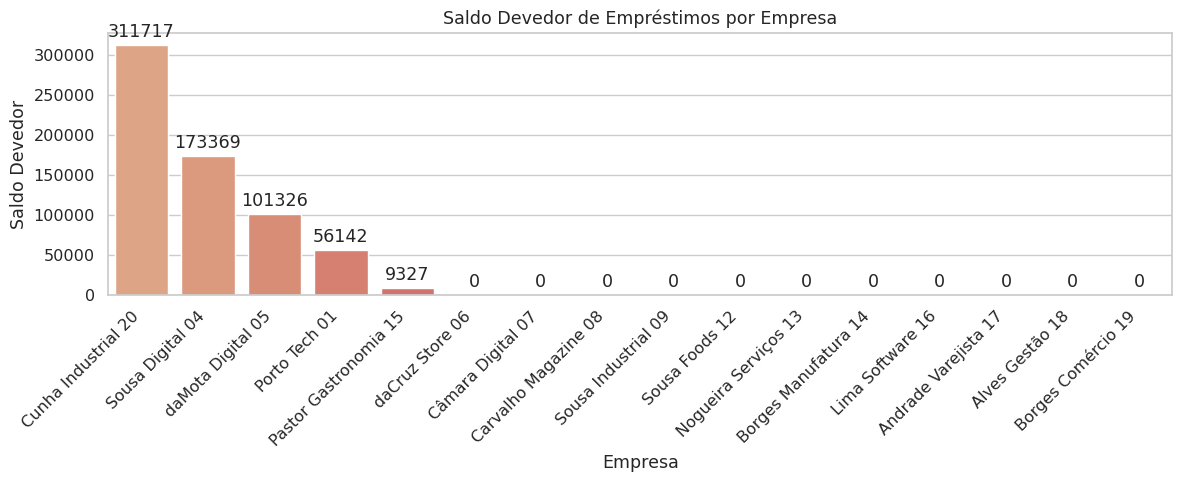

In [79]:
plt.figure(figsize=(12, 5))

ax = sns.barplot(
    data=emprestimos_por_empresa.sort_values("saldo_devedor", ascending=False),
    x="nome_empresa",
    y="saldo_devedor",
    hue="nome_empresa",
    palette="flare",
    legend=False
)

plt.title("Saldo Devedor de Empréstimos por Empresa")
plt.xlabel("Empresa")
plt.ylabel("Saldo Devedor")
plt.xticks(rotation=45, ha="right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

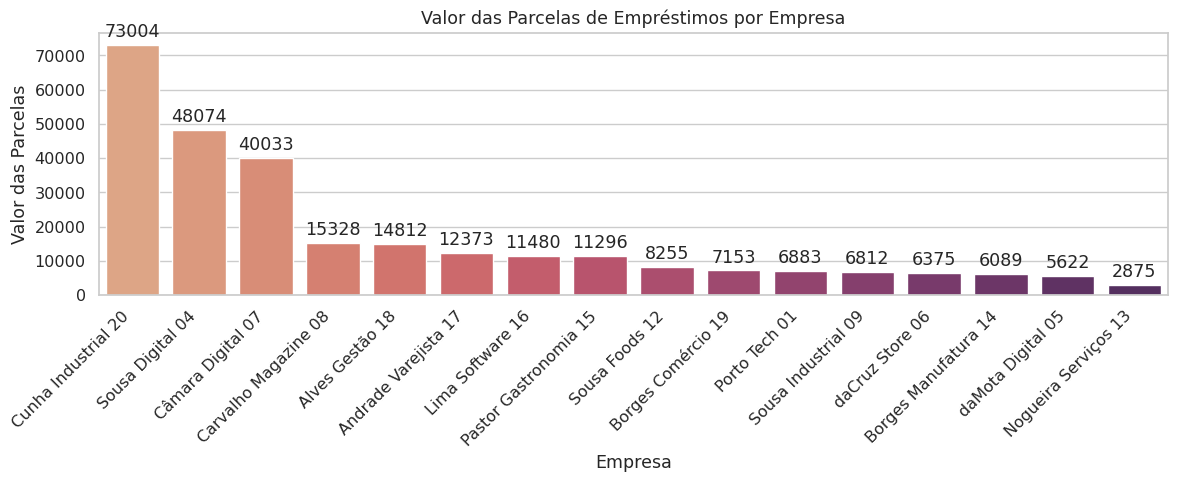

In [80]:
plt.figure(figsize=(12, 5))

ax = sns.barplot(
    data=emprestimos_por_empresa.sort_values("valor_parcelas", ascending=False),
    x="nome_empresa",
    y="valor_parcelas",
    hue="nome_empresa",
    palette="flare",
    legend=False
)

plt.title("Valor das Parcelas de Empréstimos por Empresa")
plt.xlabel("Empresa")
plt.ylabel("Valor das Parcelas")
plt.xticks(rotation=45, ha="right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

In [81]:
pressao_media_parcela_empresa = emprestimos_por_empresa["valor_parcelas"].mean()
maior_pressao_parcela_empresa = emprestimos_por_empresa["valor_parcelas"].max()
maior_saldo_devedor_empresa = emprestimos_por_empresa["saldo_devedor"].max()

percentual_empresas_com_emprestimos = round(
    total_empresas_com_emprestimos / dfs_tabelas["empresas"]["id_empresa"].nunique() * 100,
    2
)

if percentual_saldo_sobre_contratado <= 30 and valor_total_parcelas <= valor_total_contratado * 0.05:
    status_pressao_emprestimos = "Aprovado"
    interpretacao_pressao_emprestimos = "Os empréstimos geram pressão financeira controlada."
elif percentual_saldo_sobre_contratado <= 60:
    status_pressao_emprestimos = "Atenção"
    interpretacao_pressao_emprestimos = "Os empréstimos geram pressão financeira relevante, mas ainda administrável."
else:
    status_pressao_emprestimos = "Revisar"
    interpretacao_pressao_emprestimos = "Os empréstimos geram pressão financeira elevada."

avaliacao_pressao_emprestimos = pd.DataFrame({
    "indicador": [
        "Empresas com empréstimos (%)",
        "Valor total contratado",
        "Saldo devedor total",
        "Valor total das parcelas",
        "Saldo devedor sobre valor contratado (%)",
        "Maior saldo devedor por empresa",
        "Maior pressão mensal de parcelas por empresa",
        "Status da pressão financeira",
        "Interpretação"
    ],
    "valor": [
        percentual_empresas_com_emprestimos,
        round(valor_total_contratado, 2),
        round(saldo_devedor_total, 2),
        round(valor_total_parcelas, 2),
        percentual_saldo_sobre_contratado,
        round(maior_saldo_devedor_empresa, 2),
        round(maior_pressao_parcela_empresa, 2),
        status_pressao_emprestimos,
        interpretacao_pressao_emprestimos
    ]
})

display(avaliacao_pressao_emprestimos)

,indicador,valor
0,Empresas com empréstimos (%),80.0
1,Valor total contratado,5252149.3
2,Saldo devedor total,651879.99
3,Valor total das parcelas,276465.28
4,Saldo devedor sobre valor contratado (%),12.41
5,Maior saldo devedor por empresa,311716.67
6,Maior pressão mensal de parcelas por empresa,73004.25
7,Status da pressão financeira,Atenção
8,Interpretação,Os empréstimos geram pressão financeira releva...


## Resposta da Pergunta de Negócio 10

### Os empréstimos geram pressão financeira relevante?

A análise dos empréstimos avaliou se os contratos registrados na tabela `emprestimos` representam uma pressão financeira relevante para as empresas do projeto FinSight AI.

O resultado mostrou que **80% das empresas possuem empréstimos registrados**, indicando que a dívida financeira está presente em parte relevante da base. O valor total contratado foi de **5.252.149,30**, enquanto o saldo devedor total atual é de **651.879,99**.

Apesar da presença de empréstimos em várias empresas, o saldo devedor representa apenas **12,41%** do valor total contratado. Isso indica que boa parte dos contratos já foi quitada ou teve redução relevante do saldo pendente.

Na análise por status, foram identificados **6 empréstimos ativos**, com saldo devedor total de **651.879,99**, e **16 empréstimos quitados**, sem saldo devedor em aberto. Porém, mesmo os contratos quitados ainda aparecem com valor de parcelas registrado, o que é importante considerar na interpretação dos dados, pois o impacto atual sobre o caixa deve ser analisado principalmente pelos contratos ativos.

A maior concentração de saldo devedor aparece em empresas específicas, com destaque para **Cunha Industrial 20**, **Sousa Digital 04**, **daMota Digital 05**, **Porto Tech 01** e **Pastor Gastronomia 15**. Essas empresas concentram a maior parte da dívida financeira ainda em aberto e devem receber atenção em análises futuras de liquidez.

Além disso, o valor total das parcelas foi de **276.465,28**, com maior pressão mensal observada em **Cunha Industrial 20**, que possui parcelas de **73.004,25**. Esse volume de parcelas indica que, mesmo com saldo devedor proporcionalmente baixo, ainda existe impacto financeiro relevante sobre o fluxo de caixa de algumas empresas.

Portanto, a base está aprovada com atenção no critério de pressão financeira por empréstimos. Os empréstimos não indicam uma situação crítica de endividamento geral, mas geram pressão localizada em algumas empresas, principalmente nas que possuem maior saldo devedor e maior valor mensa<div style="background-color:#e8f5e9; border-left:5px solid #2e7d32; padding:12px; border-radius:6px;">rder-radius:6px;">

**Conclusão:**  
Os empréstimos geram pressão financeira relevante, mas administrável. Embora **80% das empresas** possuam empréstimos registrados, o saldo devedor atual representa apenas **12,41%** do valor total contratado. Ainda assim, algumas empresas concentram maior saldo devedor e maior valor de parcelas, especialmente **Cunha Industrial 20**, exigindo atenção nas análises de liquidez, endividamento e risco financeiro no projeto FinSight AI.

</div>

## 11. O cenário macroeconômico cobre o período analisado?

Nesta etapa, avaliamos se a tabela de cenário macroeconômico possui cobertura temporal compatível com o período analisado na base de fluxo de caixa mensal.

Essa validação é importante porque variáveis macroeconômicas, como inflação e taxa Selic, podem influenciar diretamente o comportamento financeiro das empresas, afetando receitas, despesas, custo de crédito, inadimplência e risco de liquidez.

Para que essas variáveis possam ser utilizadas na etapa de engenharia de atributos, é necessário garantir que exista informação macroeconômica para todos os meses presentes na base principal.

Serão avaliados:

- primeiro e último mês disponível no fluxo de caixa mensal;
- primeiro e último mês disponível no cenário macroeconômico;
- quantidade de meses no fluxo de caixa;
- quantidade de meses no cenário macroeconômico;
- meses do fluxo sem correspondência macroeconômica;
- suficiência da cobertura macroeconômica para modelagem.

In [82]:
if "vw_fluxo_caixa_mensal" in dfs_tabelas:
    df_fluxo_macro = dfs_tabelas["vw_fluxo_caixa_mensal"].copy()
else:
    df_fluxo_macro = pd.read_sql(
        "SELECT * FROM finsight.vw_fluxo_caixa_mensal;",
        engine
    )

if "cenario_macroeconomico" in dfs_tabelas:
    df_macro = dfs_tabelas["cenario_macroeconomico"].copy()
else:
    df_macro = pd.read_sql(
        "SELECT * FROM finsight.cenario_macroeconomico;",
        engine
    )

df_fluxo_macro.columns = df_fluxo_macro.columns.str.lower().str.strip()
df_macro.columns = df_macro.columns.str.lower().str.strip()

display(df_fluxo_macro.head())
display(df_macro.head())

print("Colunas disponíveis na base de fluxo mensal:")
print(df_fluxo_macro.columns.tolist())

print("\nColunas disponíveis na tabela de cenário macroeconômico:")
print(df_macro.columns.tolist())

,id_empresa,nome_empresa,setor,porte,mes_referencia,total_entradas,total_saidas,saldo_mes,qtd_transacoes,saldo_medio_diario,saldo_acumulado
0,1,Porto Tech 01,Tecnologia,Média,2023-01-01,217460.81,404763.73,-187302.92,18.0,-15608.576667,-187302.92
1,1,Porto Tech 01,Tecnologia,Média,2023-02-01,207526.04,264659.26,-57133.22,23.0,-4080.944286,-244436.14
2,1,Porto Tech 01,Tecnologia,Média,2023-03-01,269862.64,366060.26,-96197.62,50.0,-4809.881000,-340633.76
3,1,Porto Tech 01,Tecnologia,Média,2023-04-01,511007.83,410198.35,100809.48,45.0,4800.451429,-239824.28
4,1,Porto Tech 01,Tecnologia,Média,2023-05-01,484890.52,465891.98,18998.54,50.0,791.605833,-220825.74


,id_cenario,mes_referencia,inflacao_mensal_pct,selic_anual_pct,data_criacao
0,1,2023-01-01,0.4798,13.7334,2026-06-19 15:44:03.285441
1,2,2023-02-01,0.5285,13.8328,2026-06-19 15:44:03.285441
2,3,2023-03-01,0.5133,13.5219,2026-06-19 15:44:03.285441
3,4,2023-04-01,0.6561,13.5421,2026-06-19 15:44:03.285441
4,5,2023-05-01,0.5616,13.4151,2026-06-19 15:44:03.285441


Colunas disponíveis na base de fluxo mensal:
['id_empresa', 'nome_empresa', 'setor', 'porte', 'mes_referencia', 'total_entradas', 'total_saidas', 'saldo_mes', 'qtd_transacoes', 'saldo_medio_diario', 'saldo_acumulado']

Colunas disponíveis na tabela de cenário macroeconômico:
['id_cenario', 'mes_referencia', 'inflacao_mensal_pct', 'selic_anual_pct', 'data_criacao']


In [83]:
coluna_mes_fluxo = "mes_referencia"
coluna_mes_macro = "mes_referencia"

colunas_necessarias_fluxo = [
    coluna_mes_fluxo
]

colunas_necessarias_macro = [
    coluna_mes_macro
]

colunas_ausentes_fluxo = [
    coluna for coluna in colunas_necessarias_fluxo
    if coluna not in df_fluxo_macro.columns
]

colunas_ausentes_macro = [
    coluna for coluna in colunas_necessarias_macro
    if coluna not in df_macro.columns
]

if len(colunas_ausentes_fluxo) > 0:
    raise ValueError(f"Colunas ausentes na view de fluxo mensal: {colunas_ausentes_fluxo}")

if len(colunas_ausentes_macro) > 0:
    raise ValueError(f"Colunas ausentes na tabela de cenário macroeconômico: {colunas_ausentes_macro}")

df_fluxo_macro[coluna_mes_fluxo] = pd.to_datetime(df_fluxo_macro[coluna_mes_fluxo])
df_macro[coluna_mes_macro] = pd.to_datetime(df_macro[coluna_mes_macro])

print("Colunas identificadas com sucesso:")
print(f"Mês do fluxo de caixa: {coluna_mes_fluxo}")
print(f"Mês do cenário macroeconômico: {coluna_mes_macro}")

Colunas identificadas com sucesso:
Mês do fluxo de caixa: mes_referencia
Mês do cenário macroeconômico: mes_referencia


In [84]:
meses_fluxo = (
    df_fluxo_macro[[coluna_mes_fluxo]]
    .drop_duplicates()
    .rename(columns={coluna_mes_fluxo: "mes_referencia"})
    .sort_values("mes_referencia")
)

meses_macro = (
    df_macro[[coluna_mes_macro]]
    .drop_duplicates()
    .rename(columns={coluna_mes_macro: "mes_referencia"})
    .sort_values("mes_referencia")
)

primeiro_mes_fluxo = meses_fluxo["mes_referencia"].min()
ultimo_mes_fluxo = meses_fluxo["mes_referencia"].max()

primeiro_mes_macro = meses_macro["mes_referencia"].min()
ultimo_mes_macro = meses_macro["mes_referencia"].max()

qtd_meses_fluxo = meses_fluxo["mes_referencia"].nunique()
qtd_meses_macro = meses_macro["mes_referencia"].nunique()

resumo_periodo_macro = pd.DataFrame({
    "indicador": [
        "Primeiro mês do fluxo de caixa",
        "Último mês do fluxo de caixa",
        "Quantidade de meses no fluxo de caixa",
        "Primeiro mês do cenário macroeconômico",
        "Último mês do cenário macroeconômico",
        "Quantidade de meses no cenário macroeconômico"
    ],
    "valor": [
        primeiro_mes_fluxo.date(),
        ultimo_mes_fluxo.date(),
        qtd_meses_fluxo,
        primeiro_mes_macro.date(),
        ultimo_mes_macro.date(),
        qtd_meses_macro
    ]
})

display(resumo_periodo_macro)

,indicador,valor
0,Primeiro mês do fluxo de caixa,2022-02-01
1,Último mês do fluxo de caixa,2026-06-01
2,Quantidade de meses no fluxo de caixa,53
3,Primeiro mês do cenário macroeconômico,2023-01-01
4,Último mês do cenário macroeconômico,2026-06-01
5,Quantidade de meses no cenário macroeconômico,42


In [85]:
cobertura_macro = meses_fluxo.merge(
    meses_macro,
    on="mes_referencia",
    how="left",
    indicator=True
)

meses_sem_macro = cobertura_macro[
    cobertura_macro["_merge"] == "left_only"
][["mes_referencia"]]

qtd_meses_sem_macro = len(meses_sem_macro)

percentual_cobertura_macro = round(
    (qtd_meses_fluxo - qtd_meses_sem_macro) / qtd_meses_fluxo * 100,
    2
)

display(meses_sem_macro)

,mes_referencia
0,2022-02-01
1,2022-03-01
2,2022-04-01
3,2022-05-01
4,2022-06-01
5,2022-07-01
6,2022-08-01
7,2022-09-01
8,2022-10-01
9,2022-11-01


In [86]:
avaliacao_cobertura_macro = pd.DataFrame({
    "indicador": [
        "Meses analisados no fluxo de caixa",
        "Meses com cenário macroeconômico",
        "Meses sem cenário macroeconômico",
        "Percentual de cobertura macroeconômica (%)"
    ],
    "valor": [
        qtd_meses_fluxo,
        qtd_meses_fluxo - qtd_meses_sem_macro,
        qtd_meses_sem_macro,
        percentual_cobertura_macro
    ]
})

display(avaliacao_cobertura_macro)

,indicador,valor
0,Meses analisados no fluxo de caixa,53.00
1,Meses com cenário macroeconômico,42.00
2,Meses sem cenário macroeconômico,11.00
3,Percentual de cobertura macroeconômica (%),79.25


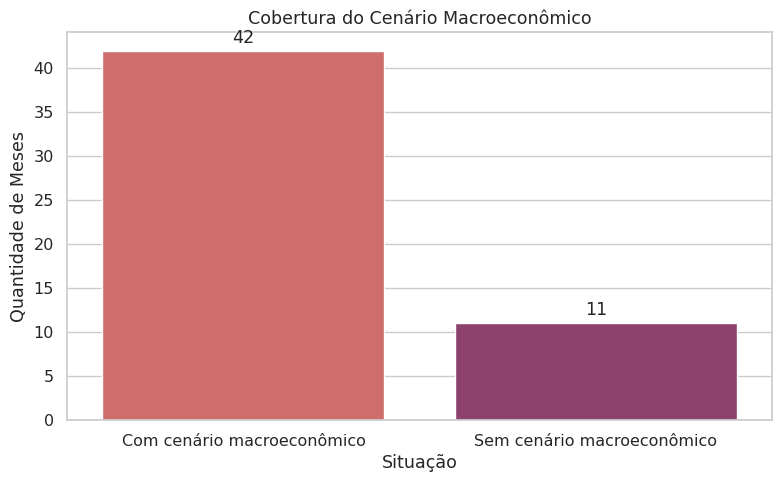

In [87]:
plt.figure(figsize=(8, 5))

df_cobertura_macro_plot = pd.DataFrame({
    "situacao": [
        "Com cenário macroeconômico",
        "Sem cenário macroeconômico"
    ],
    "qtd_meses": [
        qtd_meses_fluxo - qtd_meses_sem_macro,
        qtd_meses_sem_macro
    ]
})

ax = sns.barplot(
    data=df_cobertura_macro_plot,
    x="situacao",
    y="qtd_meses",
    hue="situacao",
    palette="flare",
    legend=False
)

plt.title("Cobertura do Cenário Macroeconômico")
plt.xlabel("Situação")
plt.ylabel("Quantidade de Meses")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

In [88]:
if percentual_cobertura_macro == 100:
    status_cobertura_macro = "Aprovado"
    interpretacao_cobertura_macro = "O cenário macroeconômico cobre todo o período analisado."
elif percentual_cobertura_macro >= 90:
    status_cobertura_macro = "Atenção"
    interpretacao_cobertura_macro = "O cenário macroeconômico cobre quase todo o período, mas existem meses sem correspondência."
else:
    status_cobertura_macro = "Revisar"
    interpretacao_cobertura_macro = "O cenário macroeconômico não cobre parte relevante do período analisado."

resultado_cobertura_macro = pd.DataFrame({
    "indicador": [
        "Primeiro mês do fluxo de caixa",
        "Último mês do fluxo de caixa",
        "Primeiro mês do cenário macroeconômico",
        "Último mês do cenário macroeconômico",
        "Meses analisados",
        "Meses sem cenário macroeconômico",
        "Cobertura macroeconômica (%)",
        "Status da cobertura",
        "Interpretação"
    ],
    "valor": [
        primeiro_mes_fluxo.date(),
        ultimo_mes_fluxo.date(),
        primeiro_mes_macro.date(),
        ultimo_mes_macro.date(),
        qtd_meses_fluxo,
        qtd_meses_sem_macro,
        percentual_cobertura_macro,
        status_cobertura_macro,
        interpretacao_cobertura_macro
    ]
})

display(resultado_cobertura_macro)

,indicador,valor
0,Primeiro mês do fluxo de caixa,2022-02-01
1,Último mês do fluxo de caixa,2026-06-01
2,Primeiro mês do cenário macroeconômico,2023-01-01
3,Último mês do cenário macroeconômico,2026-06-01
4,Meses analisados,53
5,Meses sem cenário macroeconômico,11
6,Cobertura macroeconômica (%),79.25
7,Status da cobertura,Revisar
8,Interpretação,O cenário macroeconômico não cobre parte relev...


## Resposta da Pergunta de Negócio 11

### O cenário macroeconômico cobre o período analisado?

A análise de cobertura macroeconômica avaliou se a tabela `cenario_macroeconomico` possui registros mensais compatíveis com o período analisado na base de fluxo de caixa mensal.

O resultado mostrou que a base de fluxo de caixa cobre o período de **2022-02-01** até **2026-06-01**, totalizando **53 meses analisados**. Já a tabela de cenário macroeconômico possui dados de **2023-01-01** até **2026-06-01**, com **42 meses disponíveis**.

Com isso, foram identificados **11 meses sem cenário macroeconômico correspondente**, todos localizados no início da série histórica do fluxo de caixa. A cobertura macroeconômica atual é de **79,25%**, ou seja, 42 dos 53 meses possuem dados macroeconômicos associados.

Essa diferença é relevante porque variáveis como inflação e taxa Selic podem ser utilizadas como atributos explicativos na etapa de feature engineering. Sem cobertura completa, os meses sem correspondência macroeconômica podem gerar valores nulos, perda de registros ou necessidade de tratamento antes da modelagem.

Portanto, a base não está totalmente aprovada nesse critério. Para seguir com segurança, será necessário complementar a tabela `cenario_macroeconomico` com os meses faltantes ou restringir a modelagem ao período a partir de **2023-01-01**, quando a cobertura macroeconômica passa a ser completa.

<div style="background-color:#ffebee; border-left:5px solid #c62828; padding:12px; border-radius:6px;">

**Conclusão:**  
O cenário macroeconômico não cobre integralmente o período analisado. A base de fluxo de caixa possui **53 meses**, enquanto o cenário macroeconômico cobre apenas **42 meses**, resultando em **11 meses sem correspondência** e cobertura de **79,25%**. Portanto, este critério deve ser revisado antes da etapa de engenharia de atributos, seja complementando os dados macroeconômicos faltantes ou filtrando o período de modelagem a partir de `2023-01-01`.

</div>

## 12. Existem eventos empresariais e anomalias suficientes para enriquecer os modelos?

Nesta etapa, avaliamos se existem eventos empresariais e anomalias financeiras suficientes para enriquecer as análises e os modelos preditivos do projeto FinSight AI.

Essa validação é importante porque eventos como expansão, crise, troca de gestão, renegociação de dívida ou aumento de inadimplência podem explicar mudanças relevantes no fluxo de caixa. Além disso, anomalias financeiras ajudam a identificar comportamentos fora do padrão, como quedas bruscas de saldo, saídas atípicas ou movimentos incomuns.

Essas informações podem ser usadas como variáveis explicativas na etapa de engenharia de atributos, melhorando a capacidade do modelo de interpretar oscilações e riscos.

Serão avaliados:

- quantidade total de eventos empresariais;
- quantidade total de anomalias financeiras;
- quantidade de empresas com eventos registrados;
- quantidade de empresas com anomalias registradas;
- distribuição dos eventos por tipo;
- distribuição das anomalias por tipo;
- cobertura das empresas com eventos e anomalias;
- suficiência dessas informações para enriquecer a modelagem.

In [89]:
if "eventos_empresariais" in dfs_tabelas:
    df_eventos = dfs_tabelas["eventos_empresariais"].copy()
else:
    df_eventos = pd.read_sql(
        "SELECT * FROM finsight.eventos_empresariais;",
        engine
    )

if "anomalias_financeiras" in dfs_tabelas:
    df_anomalias = dfs_tabelas["anomalias_financeiras"].copy()
else:
    df_anomalias = pd.read_sql(
        "SELECT * FROM finsight.anomalias_financeiras;",
        engine
    )

df_eventos.columns = df_eventos.columns.str.lower().str.strip()
df_anomalias.columns = df_anomalias.columns.str.lower().str.strip()

display(df_eventos.head())
display(df_anomalias.head())

print("Colunas disponíveis na tabela eventos_empresariais:")
print(df_eventos.columns.tolist())

print("\nColunas disponíveis na tabela anomalias_financeiras:")
print(df_anomalias.columns.tolist())

,id_evento,id_empresa,tipo_evento,data_inicio,data_fim,multiplicador_receita,multiplicador_despesa,descricao,data_criacao
0,1,1,Compra de Equipamento,2024-08-07,2024-10-15,1.0197,1.3692,Compra de Equipamento simulada para fins analí...,2026-06-19 15:44:03.285441
1,2,2,Compra de Equipamento,2023-11-14,2023-12-23,0.9797,1.4406,Compra de Equipamento simulada para fins analí...,2026-06-19 15:44:03.285441
2,3,2,Campanha Promocional,2026-01-15,2026-02-06,1.3094,1.0643,Campanha Promocional simulada para fins analít...,2026-06-19 15:44:03.285441
3,4,3,Campanha Promocional,2023-11-19,2023-12-11,1.3690,1.0700,Campanha Promocional simulada para fins analít...,2026-06-19 15:44:03.285441
4,5,4,Interrupção Operacional,2024-04-26,2024-07-01,0.5896,1.2171,Interrupção Operacional simulada para fins ana...,2026-06-19 15:44:03.285441


,id_anomalia,id_empresa,tipo_anomalia,data_evento,valor_original,valor_anomalo,origem,descricao,data_criacao
0,1,1,Valor Excepcional,2023-09-13,3559.95,17843.46,entrada,Anomalia sintética criada para detecção analít...,2026-06-19 15:44:03.285441
1,2,1,Possível Duplicidade,2024-08-01,1476.46,8023.72,entrada,Anomalia sintética criada para detecção analít...,2026-06-19 15:44:03.285441
2,3,1,Recebimento Atípico,2025-03-03,18154.57,42277.36,entrada,Anomalia sintética criada para detecção analít...,2026-06-19 15:44:03.285441
3,4,1,Valor Excepcional,2025-07-23,15144.77,56386.12,entrada,Anomalia sintética criada para detecção analít...,2026-06-19 15:44:03.285441
4,5,2,Recebimento Atípico,2023-12-16,5993.36,20258.03,entrada,Anomalia sintética criada para detecção analít...,2026-06-19 15:44:03.285441


Colunas disponíveis na tabela eventos_empresariais:
['id_evento', 'id_empresa', 'tipo_evento', 'data_inicio', 'data_fim', 'multiplicador_receita', 'multiplicador_despesa', 'descricao', 'data_criacao']

Colunas disponíveis na tabela anomalias_financeiras:
['id_anomalia', 'id_empresa', 'tipo_anomalia', 'data_evento', 'valor_original', 'valor_anomalo', 'origem', 'descricao', 'data_criacao']


In [90]:
def encontrar_coluna(possibilidades, colunas):
    for coluna in possibilidades:
        if coluna in colunas:
            return coluna
    return None

coluna_empresa_eventos = encontrar_coluna(
    ["id_empresa", "empresa_id"],
    df_eventos.columns
)

coluna_tipo_evento = encontrar_coluna(
    ["tipo_evento", "evento", "categoria_evento", "tipo"],
    df_eventos.columns
)

coluna_data_evento = encontrar_coluna(
    ["data_evento", "mes_referencia", "data_referencia", "data"],
    df_eventos.columns
)

coluna_empresa_anomalias = encontrar_coluna(
    ["id_empresa", "empresa_id"],
    df_anomalias.columns
)

coluna_tipo_anomalia = encontrar_coluna(
    ["tipo_anomalia", "anomalia", "categoria_anomalia", "tipo"],
    df_anomalias.columns
)

coluna_data_anomalia = encontrar_coluna(
    ["data_anomalia", "mes_referencia", "data_referencia", "data"],
    df_anomalias.columns
)

colunas_necessarias_eventos = [
    coluna_empresa_eventos,
    coluna_tipo_evento
]

colunas_necessarias_anomalias = [
    coluna_empresa_anomalias,
    coluna_tipo_anomalia
]

if any(coluna is None for coluna in colunas_necessarias_eventos):
    raise ValueError("Não foi possível identificar as colunas mínimas da tabela eventos_empresariais.")

if any(coluna is None for coluna in colunas_necessarias_anomalias):
    raise ValueError("Não foi possível identificar as colunas mínimas da tabela anomalias_financeiras.")

if coluna_data_evento is not None:
    df_eventos[coluna_data_evento] = pd.to_datetime(df_eventos[coluna_data_evento], errors="coerce")

if coluna_data_anomalia is not None:
    df_anomalias[coluna_data_anomalia] = pd.to_datetime(df_anomalias[coluna_data_anomalia], errors="coerce")

print("Colunas identificadas com sucesso:")
print(f"Empresa eventos: {coluna_empresa_eventos}")
print(f"Tipo evento: {coluna_tipo_evento}")
print(f"Data evento: {coluna_data_evento}")
print(f"Empresa anomalias: {coluna_empresa_anomalias}")
print(f"Tipo anomalia: {coluna_tipo_anomalia}")
print(f"Data anomalia: {coluna_data_anomalia}")

Colunas identificadas com sucesso:
Empresa eventos: id_empresa
Tipo evento: tipo_evento
Data evento: None
Empresa anomalias: id_empresa
Tipo anomalia: tipo_anomalia
Data anomalia: None


In [91]:
total_empresas = dfs_tabelas["empresas"]["id_empresa"].nunique()

total_eventos = len(df_eventos)
total_anomalias = len(df_anomalias)

empresas_com_eventos = df_eventos[coluna_empresa_eventos].nunique()
empresas_com_anomalias = df_anomalias[coluna_empresa_anomalias].nunique()

percentual_empresas_com_eventos = round(
    empresas_com_eventos / total_empresas * 100,
    2
)

percentual_empresas_com_anomalias = round(
    empresas_com_anomalias / total_empresas * 100,
    2
)

resumo_eventos_anomalias = pd.DataFrame({
    "indicador": [
        "Total de empresas",
        "Total de eventos empresariais",
        "Total de anomalias financeiras",
        "Empresas com eventos",
        "Empresas com anomalias",
        "Percentual de empresas com eventos (%)",
        "Percentual de empresas com anomalias (%)"
    ],
    "valor": [
        total_empresas,
        total_eventos,
        total_anomalias,
        empresas_com_eventos,
        empresas_com_anomalias,
        percentual_empresas_com_eventos,
        percentual_empresas_com_anomalias
    ]
})

display(resumo_eventos_anomalias)

,indicador,valor
0,Total de empresas,20.0
1,Total de eventos empresariais,30.0
2,Total de anomalias financeiras,298.0
3,Empresas com eventos,18.0
4,Empresas com anomalias,20.0
5,Percentual de empresas com eventos (%),90.0
6,Percentual de empresas com anomalias (%),100.0


In [92]:
distribuicao_eventos = (
    df_eventos
    .groupby(coluna_tipo_evento)
    .agg(qtd_eventos=(coluna_empresa_eventos, "count"))
    .reset_index()
    .sort_values("qtd_eventos", ascending=False)
)

distribuicao_eventos["percentual"] = (
    distribuicao_eventos["qtd_eventos"] / total_eventos * 100
).round(2)

display(distribuicao_eventos)

,tipo_evento,qtd_eventos,percentual
5,Perda de Cliente Relevante,7,23.33
0,Campanha Promocional,5,16.67
1,Compra de Equipamento,5,16.67
3,Expansão Comercial,5,16.67
2,Crise de Receita,4,13.33
4,Interrupção Operacional,4,13.33


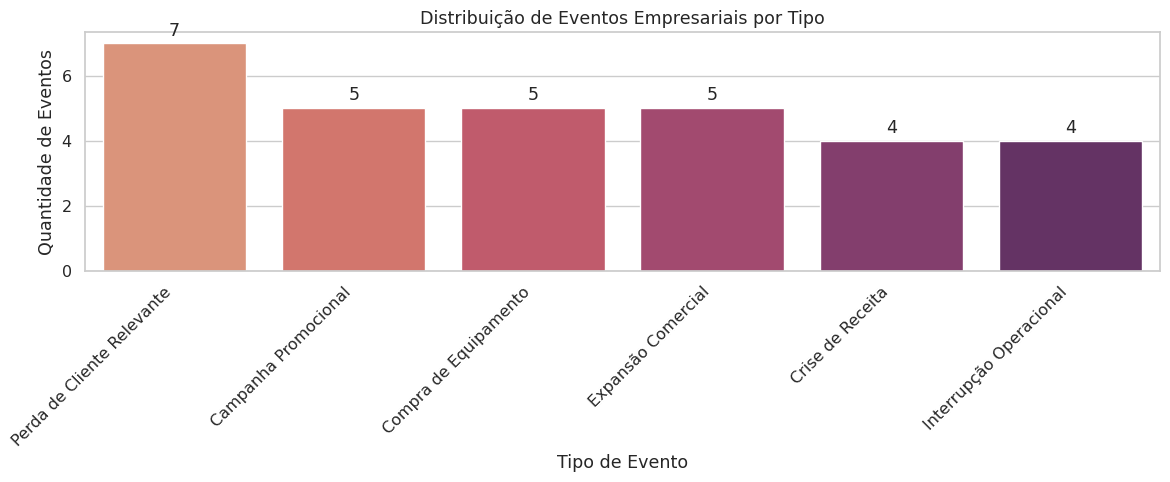

In [93]:
plt.figure(figsize=(12, 5))

ax = sns.barplot(
    data=distribuicao_eventos,
    x=coluna_tipo_evento,
    y="qtd_eventos",
    hue=coluna_tipo_evento,
    palette="flare",
    legend=False
)

plt.title("Distribuição de Eventos Empresariais por Tipo")
plt.xlabel("Tipo de Evento")
plt.ylabel("Quantidade de Eventos")
plt.xticks(rotation=45, ha="right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

In [94]:
distribuicao_anomalias = (
    df_anomalias
    .groupby(coluna_tipo_anomalia)
    .agg(qtd_anomalias=(coluna_empresa_anomalias, "count"))
    .reset_index()
    .sort_values("qtd_anomalias", ascending=False)
)

distribuicao_anomalias["percentual"] = (
    distribuicao_anomalias["qtd_anomalias"] / total_anomalias * 100
).round(2)

display(distribuicao_anomalias)

,tipo_anomalia,qtd_anomalias,percentual
2,Possível Duplicidade,108,36.24
4,Valor Excepcional,83,27.85
3,Recebimento Atípico,79,26.51
0,Despesa Atípica,14,4.70
1,Pagamento Excepcional,14,4.70


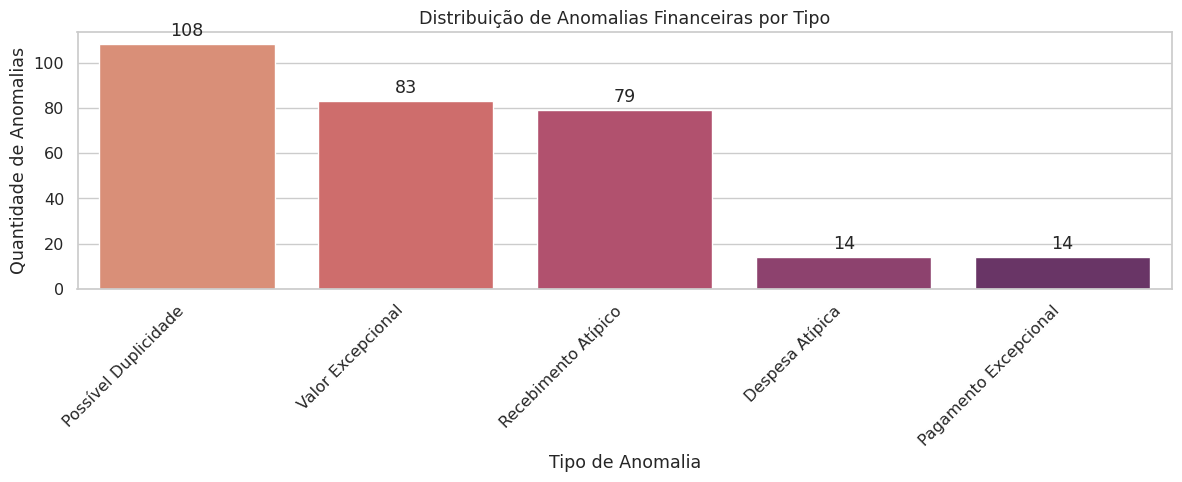

In [95]:
plt.figure(figsize=(12, 5))

ax = sns.barplot(
    data=distribuicao_anomalias,
    x=coluna_tipo_anomalia,
    y="qtd_anomalias",
    hue=coluna_tipo_anomalia,
    palette="flare",
    legend=False
)

plt.title("Distribuição de Anomalias Financeiras por Tipo")
plt.xlabel("Tipo de Anomalia")
plt.ylabel("Quantidade de Anomalias")
plt.xticks(rotation=45, ha="right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

In [96]:
eventos_por_empresa = (
    df_eventos
    .groupby(coluna_empresa_eventos)
    .agg(qtd_eventos=(coluna_tipo_evento, "count"))
    .reset_index()
    .rename(columns={coluna_empresa_eventos: "id_empresa"})
)

anomalias_por_empresa = (
    df_anomalias
    .groupby(coluna_empresa_anomalias)
    .agg(qtd_anomalias=(coluna_tipo_anomalia, "count"))
    .reset_index()
    .rename(columns={coluna_empresa_anomalias: "id_empresa"})
)

df_empresas_eventos_anomalias = dfs_tabelas["empresas"].copy()
df_empresas_eventos_anomalias.columns = df_empresas_eventos_anomalias.columns.str.lower().str.strip()

cobertura_eventos_anomalias = (
    df_empresas_eventos_anomalias[["id_empresa", "nome_empresa"]]
    .merge(eventos_por_empresa, on="id_empresa", how="left")
    .merge(anomalias_por_empresa, on="id_empresa", how="left")
)

cobertura_eventos_anomalias["qtd_eventos"] = cobertura_eventos_anomalias["qtd_eventos"].fillna(0).astype(int)
cobertura_eventos_anomalias["qtd_anomalias"] = cobertura_eventos_anomalias["qtd_anomalias"].fillna(0).astype(int)

cobertura_eventos_anomalias["possui_evento"] = cobertura_eventos_anomalias["qtd_eventos"] > 0
cobertura_eventos_anomalias["possui_anomalia"] = cobertura_eventos_anomalias["qtd_anomalias"] > 0

display(cobertura_eventos_anomalias)

,id_empresa,nome_empresa,qtd_eventos,qtd_anomalias,possui_evento,possui_anomalia
0,1,Porto Tech 01,1,6,True,True
1,2,Camargo Comércio 02,2,7,True,True
2,3,Alves Foods 03,1,3,True,True
3,4,Sousa Digital 04,1,42,True,True
4,5,daMota Digital 05,1,9,True,True
5,6,daCruz Store 06,1,6,True,True
6,7,Câmara Digital 07,2,36,True,True
7,8,Carvalho Magazine 08,3,17,True,True
8,9,Sousa Industrial 09,2,7,True,True
9,10,Caldeira Digital 10,1,4,True,True


In [97]:
cobertura_resumo = pd.DataFrame({
    "situacao": [
        "Empresas com eventos",
        "Empresas sem eventos",
        "Empresas com anomalias",
        "Empresas sem anomalias"
    ],
    "qtd_empresas": [
        cobertura_eventos_anomalias["possui_evento"].sum(),
        total_empresas - cobertura_eventos_anomalias["possui_evento"].sum(),
        cobertura_eventos_anomalias["possui_anomalia"].sum(),
        total_empresas - cobertura_eventos_anomalias["possui_anomalia"].sum()
    ]
})

display(cobertura_resumo)

,situacao,qtd_empresas
0,Empresas com eventos,18
1,Empresas sem eventos,2
2,Empresas com anomalias,20
3,Empresas sem anomalias,0


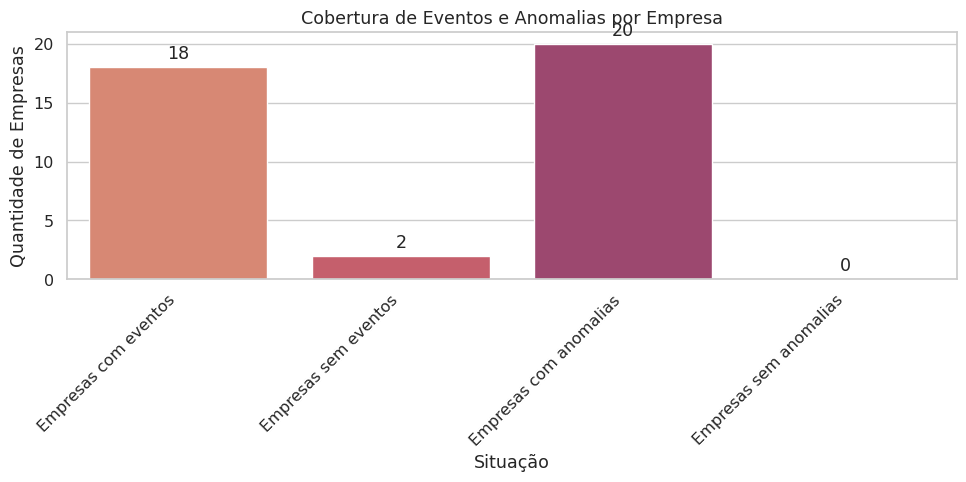

In [98]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=cobertura_resumo,
    x="situacao",
    y="qtd_empresas",
    hue="situacao",
    palette="flare",
    legend=False
)

plt.title("Cobertura de Eventos e Anomalias por Empresa")
plt.xlabel("Situação")
plt.ylabel("Quantidade de Empresas")
plt.xticks(rotation=45, ha="right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

In [99]:
if percentual_empresas_com_eventos >= 80 and percentual_empresas_com_anomalias >= 80:
    status_eventos_anomalias = "Aprovado"
    interpretacao_eventos_anomalias = "A base possui eventos e anomalias suficientes para enriquecer a modelagem."
elif percentual_empresas_com_eventos >= 50 and percentual_empresas_com_anomalias >= 50:
    status_eventos_anomalias = "Atenção"
    interpretacao_eventos_anomalias = "A base possui eventos e anomalias úteis, mas com cobertura parcial entre as empresas."
else:
    status_eventos_anomalias = "Revisar"
    interpretacao_eventos_anomalias = "A base possui baixa cobertura de eventos ou anomalias, limitando o enriquecimento dos modelos."

avaliacao_eventos_anomalias = pd.DataFrame({
    "indicador": [
        "Total de eventos empresariais",
        "Total de anomalias financeiras",
        "Empresas com eventos",
        "Empresas com anomalias",
        "Percentual de empresas com eventos (%)",
        "Percentual de empresas com anomalias (%)",
        "Status da cobertura",
        "Interpretação"
    ],
    "valor": [
        total_eventos,
        total_anomalias,
        empresas_com_eventos,
        empresas_com_anomalias,
        percentual_empresas_com_eventos,
        percentual_empresas_com_anomalias,
        status_eventos_anomalias,
        interpretacao_eventos_anomalias
    ]
})

display(avaliacao_eventos_anomalias)

,indicador,valor
0,Total de eventos empresariais,30
1,Total de anomalias financeiras,298
2,Empresas com eventos,18
3,Empresas com anomalias,20
4,Percentual de empresas com eventos (%),90.0
5,Percentual de empresas com anomalias (%),100.0
6,Status da cobertura,Aprovado
7,Interpretação,A base possui eventos e anomalias suficientes ...


## Resposta da Pergunta de Negócio 12

### Existem eventos empresariais e anomalias suficientes para enriquecer os modelos?

A análise avaliou se a base possui eventos empresariais e anomalias financeiras suficientes para enriquecer as análises e os modelos preditivos do projeto FinSight AI.

O resultado mostrou que existem **30 eventos empresariais** registrados e **298 anomalias financeiras** identificadas na base. Em relação à cobertura por empresa, **18 das 20 empresas** possuem eventos registrados, representando **90% da base**, enquanto **todas as 20 empresas** possuem anomalias financeiras, atingindo **100% de cobertura**.

Na distribuição dos eventos empresariais, o tipo mais frequente foi **Perda de Cliente Relevante**, com 7 ocorrências, representando **23,33%** dos eventos. Também aparecem eventos como **Campanha Promocional**, **Compra de Equipamento** e **Expansão Comercial**, cada um com 5 ocorrências, além de **Crise de Receita** e **Interrupção Operacional**, com 4 ocorrências cada.

Essa diversidade de eventos é positiva porque permite associar mudanças no fluxo de caixa a acontecimentos relevantes do negócio. Por exemplo, uma perda de cliente pode explicar queda de receita, uma expansão comercial pode justificar aumento de despesas, e uma compra de equipamento pode gerar uma saída atípica de caixa.

Na análise das anomalias financeiras, os principais tipos identificados foram **Possível Duplicidade**, com 108 ocorrências, **Valor Excepcional**, com 83 ocorrências, e **Recebimento Atípico**, com 79 ocorrências. Também foram observadas anomalias de **Despesa Atípica** e **Pagamento Excepcional**, ambas com 14 ocorrências.

Essas anomalias são importantes para a modelagem porque ajudam a sinalizar comportamentos fora do padrão, permitindo criar variáveis explicativas para movimentos financeiros incomuns. Elas também podem apoiar análises de qualidade dos dados, risco operacional e identificação de eventos que impactam diretamente o caixa.

Portanto, a base está aprovada no critério de enriquecimento por eventos e anomalias. A cobertura é ampla, os eventos possuem diversidade relevante e as anomalias aparecem em todas as empresas, oferecendo informações úteis para a etapa de engenharia de atributos e modelagem.

<div style="background-color:#e8f5e9; border-left:5px solid #2e7d32; padding:12px; border-radius:6px;">

**Conclusão:**  
A base possui eventos empresariais e anomalias financeiras suficientes para enriquecer os modelos. Foram identificados **30 eventos empresariais**, com cobertura em **90% das empresas**, e **298 anomalias financeiras**, com cobertura em **100% das empresas**. Portanto, essas informações estão aprovadas para uso como variáveis explicativas na engenharia de atributos, contribuindo para análises de fluxo de caixa, comportamento financeiro e risco de liquidez no projeto FinSight AI.

</div>

## 13. A base está pronta para avançar para engenharia de atributos?

Nesta etapa, consolidamos os principais resultados da análise exploratória para avaliar se a base está pronta para avançar para o notebook `02_feature_engineering.ipynb`.

Essa validação final é importante porque a engenharia de atributos depende dos critérios já analisados anteriormente, como consistência das tabelas, histórico temporal suficiente, diversidade da base, variação financeira, cobertura das tabelas auxiliares e disponibilidade de variáveis explicativas.

Nesta consolidação, são considerados os resultados já avaliados nas perguntas anteriores:

- qualidade geral das tabelas;
- presença de nulos críticos;
- existência de chaves duplicadas;
- suficiência do histórico mensal;
- diversidade entre setores e portes;
- variação do fluxo de caixa;
- situação de contas a receber e contas a pagar;
- pressão financeira dos empréstimos;
- cobertura do cenário macroeconômico;
- disponibilidade de eventos empresariais e anomalias;
- decisão final para avanço à engenharia de atributos.

## Resposta da Pergunta de Negócio 13

### A base está pronta para avançar para engenharia de atributos?

A análise exploratória consolidou os principais critérios de qualidade, cobertura, consistência e utilidade analítica da base do projeto FinSight AI.

De forma geral, os resultados mostram que a base possui estrutura suficiente para avançar para a etapa de engenharia de atributos no notebook `02_feature_engineering.ipynb`. As tabelas principais foram carregadas corretamente, não foram identificados problemas críticos de nulos ou chaves duplicadas, e o histórico mensal apresentou cobertura adequada para criação de variáveis temporais.

O histórico de fluxo de caixa é um dos pontos mais fortes da base. As 20 empresas possuem pelo menos 42 meses de dados, com média geral de 43,8 meses por empresa, permitindo a criação segura de lags, médias móveis, volatilidade, tendência e variáveis sazonais.

Além disso, o fluxo de caixa apresentou variação suficiente para modelagem. Todas as empresas foram classificadas com variação alta no `saldo_acumulado`, indicando que existe comportamento financeiro relevante a ser aprendido pelos modelos.

A base também possui diversidade setorial adequada, com 20 empresas distribuídas em 5 setores. Porém, existe concentração em empresas de porte médio e ausência de empresas de pequeno porte. Esse ponto não bloqueia a engenharia de atributos, mas deve ser considerado na interpretação dos modelos.

As contas a receber e contas a pagar apresentam situação controlada. Nas contas a receber, 96,05% do valor financeiro já foi recebido, com apenas 3,93% vencido e 0,02% em aberto. Nas contas a pagar, 97,53% do valor já foi pago, com 2,42% vencido e 0,05% em aberto. Esses percentuais indicam que existem sinais úteis para análise de liquidez, mas sem evidência de descontrole financeiro generalizado.

Os empréstimos também contribuem para enriquecer a modelagem. Embora 80% das empresas possuam empréstimos registrados, o saldo devedor atual representa apenas 12,41% do valor total contratado. Isso indica pressão financeira relevante, mas administrável, concentrada em algumas empresas específicas.

Eventos empresariais e anomalias financeiras também estão disponíveis em volume suficiente. Foram identificados 30 eventos empresariais, cobrindo 90% das empresas, e 298 anomalias financeiras, cobrindo 100% das empresas. Essas informações são úteis para criar variáveis explicativas relacionadas a mudanças bruscas no fluxo de caixa, comportamentos atípicos e eventos relevantes do negócio.

O principal ponto de atenção está na cobertura do cenário macroeconômico. A base de fluxo de caixa cobre 53 meses, de 2022-02-01 até 2026-06-01, enquanto a tabela `cenario_macroeconomico` cobre apenas 42 meses, de 2023-01-01 até 2026-06-01. Portanto, existem 11 meses sem correspondência macroeconômica, com cobertura de 79,25%.

Dessa forma, a base está pronta para avançar para engenharia de atributos, desde que o tratamento do cenário macroeconômico seja considerado. Existem duas alternativas: complementar os meses faltantes na tabela `cenario_macroeconomico` ou restringir as features macroeconômicas ao período a partir de `2023-01-01`.

<div style="background-color:#fff8e1; border-left:5px solid #f9a825; padding:12px; border-radius:6px;">

**Conclusão:**  
A base está pronta para avançar para o notebook `02_feature_engineering.ipynb`, com atenção para a cobertura do cenário macroeconômico. Os dados possuem histórico mensal suficiente, boa qualidade estrutural, variação financeira relevante, contas a receber e pagar controladas, empréstimos úteis para análise de pressão financeira, além de eventos e anomalias suficientes para enriquecer os modelos. O único ajuste necessário antes da modelagem completa é tratar os 11 meses sem cenário macroeconômico ou iniciar as features macroeconômicas a partir de `2023-01-01`.

</div>